# Multidimensional International Development Country Clustering (1964–2024)
## A Longitudinal Machine Learning Analysis of Peer Nations and Structural Transitions Across Six Decades

**Author:** Arjun Singh  
**LinkedIn:** https://www.linkedin.com/in/singharjun/  
**Project:** Capstone Project - International Development Country Clustering  
**Dataset:** World Bank World Development Indicators (WDI)  
**Time Coverage:** 1964–2024 (Six 10-Year Intervals: 1964–1973, 1974–1983, 1984–1993, 1994–2003, 2004–2013, 2014–2024)  

---

### Table of Contents
1. [Executive Summary](#1-executive-summary)
2. [Analytical Justification](#2-analytical-justification)
3. [Data Acquisition and Preparation](#3-data-acquisition-and-preparation)
4. [Data Cleaning and Quality Engineering](#4-data-cleaning-and-quality-engineering)
   - 4.1 [Duplicate Detection and Removal](#41-duplicate-detection-and-removal)
   - 4.2 [Missing Value Analysis and Threshold Filtering](#42-missing-value-analysis-and-threshold-filtering)
   - 4.3 [Outlier Assessment and Robust Capping](#43-outlier-assessment-and-robust-capping)
   - 4.4 [Consistency and Domain Boundary Checks](#44-consistency-and-domain-boundary-checks)
   - 4.5 [Missing Data Imputation via KNN](#45-missing-data-imputation-via-knn)
   - 4.6 [Feature Scaling via StandardScaler](#46-feature-scaling-via-standardscaler)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
6. [Principal Component Analysis (PCA) per Decade](#6-principal-component-analysis-pca-per-decade)
7. [Unsupervised Clustering Analysis (K-Means) & Cross-Decade Transitions](#7-unsupervised-clustering-analysis-k-means--cross-decade-transitions)
8. [Model Validation and Evaluation](#8-model-validation-and-evaluation)
9. [Longitudinal Cluster Interpretation Framework](#9-longitudinal-cluster-interpretation-framework)
10. [Policy Recommendations](#10-policy-recommendations)
11. [Findings Criteria](#11-findings-criteria)
12. [Future Recommendations](#12-future-recommendations)
13. [Conclusion](#13-conclusion)


---
# 1. Executive Summary

### 1.1 Business Objective & Context
For decades, international organizations and development finance institutions (such as the World Bank and IMF) have categorized countries primarily through single-dimensional economic thresholds most notably **Gross National Income (GNI) per capita** (Low Income, Lower-Middle Income, Upper-Middle Income, and High Income). While computationally convenient, unidimensional income classification obscures critical socioeconomic realities:
1. **The Middle-Income Trap & Inequality:** Countries with similar per-capita income often exhibit vastly divergent public health resilience, educational attainment, and infrastructure maturity.
2. **Resource-Rich Asymmetries:** Hydrocarbon and mineral-dependent economies may achieve high statistical GDP while lagging in human capital and institutional development.
3. **Peer-Country Benchmarking:** Developing nations frequently benefit more from benchmarking policies against structural peers facing identical demographic or health bottlenecks, rather than nations that merely share a GDP tier.

This research establishes a multidimensional, data-driven clustering framework that identifies groups of sovereign nations sharing systemic developmental characteristics across five core pillars: Economic Dynamism, Public Health, Educational Attainment, Demographic Transition, and Infrastructure Connectivity. Furthermore, this study tracks how cluster membership and global development topologies have evolved over a 60-year longitudinal horizon (1964–2024) divided into six 10-year intervals.

### 1.2 Research Question
> **Can we identify distinct, multidimensional developmental clusters of countries using economic, health, and social indicators and how have those clusters shifted across ten-year intervals from 1964 to 2024 to reveal "peer nations" that share similar developmental challenges despite varying income levels?**

### 1.3 Key Findings
1. **The Great Demographic-Health Divergence (1964–1983):** In the early decades, global clustering was sharply polarized along survival and demographic lines (high infant mortality + high fertility vs. low mortality + advanced industrialization).
2. **The Emergence of the Transitional Middle Tier (1984–2003):** Following structural adjustments, Asian economic expansion, and the post-Cold War reconfiguration, a robust intermediate cluster formed, characterized by rapid urbanization, expanding primary/secondary education, and surging trade integration.
3. **The Digital and Infrastructure Leap (2004–2024):** In the modern era, electrification and mobile connectivity diffused rapidly, compressing traditional infrastructure gaps. However, new axes of divergence emerged around **tertiary human capital, technological adoption (broadband/internet), and demographic aging**.
4. **Identification of Non-Income Peer Nations:** The clustering framework successfully exposes nations with comparable multidimensional profiles despite divergent income levels. For instance, several resource-rich upper-middle-income economies cluster with lower-middle-income peers due to shared bottlenecks in educational expenditure and health system burdens.
5. **Upward Mobility vs. Low-Income Traps:** While East Asian and Eastern European economies demonstrated rapid cross-decade upward mobility into advanced tiers, approximately 30+ nations in Sub-Saharan Africa and conflict-affected zones have remained structurally constrained in low-human-development clusters across all six decades.

### 1.4 Major Policy Insights
- **Governments:** Targeted reforms must align with multidimensional peer benchmarks rather than generic regional averages.
- **Multilateral Lenders:** Concessional financing and grant eligibility should integrate multidimensional vulnerability indices alongside GNI per capita.
- **NGOs & Development Agencies:** Focus resources on high-leverage structural binding constraints (e.g., secondary educational completion and maternal-infant health in persistent low-tier clusters).


---
# 2. Analytical Justification

### 2.1 Why Unsupervised Machine Learning?
Traditional development classification relies on arbitrary, politically negotiated thresholds (e.g., the World Bank's historical $1,000 GNI per capita threshold). Unsupervised machine learning provides an objective, data-driven alternative that discovers latent geometric structures in high-dimensional feature spaces without pre-imposing subjective class boundaries.

```
+-----------------------------------------------------------------------------------------------------+
|                                    METHODOLOGICAL COMPARISON                                        |
+-------------------------------+------------------------------------+--------------------------------+
| Dimension                     | Supervised Classification          | Unsupervised Clustering (Ours) |
+-------------------------------+------------------------------------+--------------------------------+
| Target Variable (Ground Truth)| Requires predefined labels (e.g.,  | None required; discovers       |
|                               | arbitrary income tiers)            | latent organic groupings       |
| Multidimensional Synthesis    | Often biased toward target metric  | Synthesizes 18 indicators      |
|                               | (e.g., GDP/GNI)                    | across 5 development pillars   |
| Discovery of Novel Paradigms  | Limited to predicting known classes| Identifies unexpected peer     |
|                               |                                    | groupings & structural traps   |
| Longitudinal Dynamics         | Rigid over time                    | Adapts organically to global   |
|                               |                                    | frontier shifts per decade     |
+-------------------------------+------------------------------------+--------------------------------+
```

### 2.2 Why K-Means Clustering?
1. **Centroid-Based Interpretability:** K-Means produces explicit cluster centroids in the feature space, allowing policymakers to inspect the exact average indicator values for each cluster (e.g., mean life expectancy, mean GDP per capita, mean trade ratio).
2. **Geometric Partitioning & Scaling:** In standardized Euclidean space (via `StandardScaler`), K-Means partitions countries into spherical, Voronoi-like polyhedra that naturally separate low, intermediate, and high developmental tiers.
3. **Computational Reproducibility:** By fixing `random_state=42`, `init='k-means++'`, and `n_init=10`, K-Means ensures 100% deterministic, publication-grade reproducibility.

### 2.3 Why Not Supervised Learning?
Supervised learning requires ground-truth labels. In international development, defining "what constitutes a developed nation" using a single label is inherently circular and income-biased. Supervised models trained on World Bank income categories would merely learn to predict GNI per capita, entirely defeating the business objective of discovering multidimensional peer nations.

### 2.4 Advantages and Methodological Limitations
- **Advantages:** Unbiased multi-pillar synthesis; robust to cross-country structural shifts; intuitive policy interpretation; clear longitudinal transition tracking.
- **Limitations:** Sensitivity to spherical cluster assumptions; sensitivity to extreme outliers (mitigated via robust winsorization and StandardScaler); missing data constraints across historical decades (mitigated via KNN imputation).


---
# 3. Data Acquisition and Preparation

### 3.1 Data Source
The primary data source is the **World Bank World Development Indicators (WDI)** database (`WDICSV.csv`, `WDICountry.csv`, `WDISeries.csv`), representing the most comprehensive global longitudinal archive of development statistics.

### 3.2 Canonical Indicator Selection
To avoid ad-hoc indicator selection, we formally specify **18 indicators** spanning **5 foundational pillars of development**:

```
====================================================================================================
PILLAR 1: ECONOMIC DYNAMISM & INTEGRATION
  - NY.GDP.PCAP.KD    : GDP per capita (constant 2015 US$) [Poverty & Economic Capacity]
  - NY.GDP.MKTP.KD.ZG : GDP growth (annual %) [Economic Momentum]
  - FP.CPI.TOTL.ZG    : Inflation, consumer prices (annual %) [Macroeconomic Stability]
  - NE.TRD.GNFS.ZS    : Trade (% of GDP) [Global Economic Integration]

PILLAR 2: PUBLIC HEALTH & SURVIVAL
  - SP.DYN.LE00.IN    : Life expectancy at birth, total (years) [Population Longevity]
  - SP.DYN.IMRT.IN    : Mortality rate, infant (per 1,000 live births) [Health System Efficacy]
  - SH.XPD.CHEX.GD.ZS : Current health expenditure (% of GDP) [Health Resource Allocation]

PILLAR 3: EDUCATIONAL ATTAINMENT & HUMAN CAPITAL
  - SE.SEC.ENRR       : School enrollment, secondary (% gross) [Workforce Readiness]
  - SE.PRM.ENRR       : School enrollment, primary (% gross) [Foundational Literacy Pipeline]
  - SE.XPD.TOTL.GD.ZS : Government expenditure on education (% of GDP) [Public Human Capital Investment]
  - SE.ADT.LITR.ZS    : Adult literacy rate (% ages 15+) [Basic Human Capital Stock]

PILLAR 4: DEMOGRAPHIC STRUCTURE & URBANIZATION
  - SP.POP.GROW       : Population growth (annual %) [Demographic Pressure]
  - SP.URB.TOTL.IN.ZS : Urban population (% of total) [Structural Economic Transformation]
  - SP.POP.DPND       : Age dependency ratio (% of working-age population) [Demographic Burden]

PILLAR 5: INFRASTRUCTURE & TECHNOLOGICAL CONNECTIVITY
  - EG.ELC.ACCS.ZS    : Access to electricity (% of population) [Basic Physical Infrastructure]
  - IT.NET.USER.ZS    : Individuals using the Internet (% of population) [Digital Economy Frontier]
  - IT.CEL.SETS.P2    : Mobile cellular subscriptions (per 100 people) [Mobile Connectivity]
  - IT.MLT.MAIN.P2    : Fixed telephone subscriptions (per 100 people) [Historical Telecommunications]
====================================================================================================
```

> **Note on Governance Indicators:** Worldwide Governance Indicators (WGI) measuring Rule of Law, Control of Corruption, and Voice & Accountability are published in a separate dataset starting from 1996. To preserve methodological consistency and prevent unaligned historical time windows across 1964–2024, governance indicators are omitted from the primary WDI clustering feature matrix and documented as a primary vector for future research.

### 3.3 Sovereign Entity Filtering & Decade-Mean Formulation
- **Exclusion of Aggregates:** We join data against `WDICountry.csv` and retain only rows with a **non-null `Region`**, filtering out all regional aggregates ("Sub-Saharan Africa", "OECD members", "World", etc.) and yielding **217 sovereign entities**.
- **Decade-Mean Formulation:** For each 10-year window, we compute the decade-mean across available years. This mitigates short-term business-cycle shocks, natural disaster anomalies, and single-year reporting gaps.


In [1]:
# Setup Environment & Global Configuration
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Configure publication-quality plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment initialized successfully.")


Environment initialized successfully.


In [2]:
# Load Raw WDI Data and Filter Sovereign Nations
data_dir = 'data'
country_file = os.path.join(data_dir, 'WDICountry.csv')
series_file = os.path.join(data_dir, 'WDISeries.csv')
data_file = os.path.join(data_dir, 'WDICSV.csv') if os.path.exists(os.path.join(data_dir, 'WDICSV.csv')) else os.path.join(data_dir, 'WDIData.csv')

# Load country metadata
df_country = pd.read_csv(country_file)
# Filter sovereign countries with non-null Region
df_sovereign = df_country[df_country['Region'].notna()][['Country Code', 'Short Name', 'Table Name', 'Region', 'Income Group']].copy()
valid_country_codes = set(df_sovereign['Country Code'].unique())
print(f"Total sovereign entities identified (non-null Region): {len(valid_country_codes)}")

# Define indicator metadata mapping
indicators_meta = {
    # Economic
    'NY.GDP.PCAP.KD': {'name': 'GDP_per_capita', 'cat': 'Economic', 'bounded_0_100': False, 'non_neg': True},
    'NY.GDP.MKTP.KD.ZG': {'name': 'GDP_growth_pct', 'cat': 'Economic', 'bounded_0_100': False, 'non_neg': False},
    'FP.CPI.TOTL.ZG': {'name': 'Inflation_pct', 'cat': 'Economic', 'bounded_0_100': False, 'non_neg': False},
    'NE.TRD.GNFS.ZS': {'name': 'Trade_pct_GDP', 'cat': 'Economic', 'bounded_0_100': False, 'non_neg': True},
    
    # Health
    'SP.DYN.LE00.IN': {'name': 'Life_expectancy', 'cat': 'Health', 'bounded_0_100': False, 'non_neg': True},
    'SP.DYN.IMRT.IN': {'name': 'Infant_mortality', 'cat': 'Health', 'bounded_0_100': False, 'non_neg': True},
    'SH.XPD.CHEX.GD.ZS': {'name': 'Health_expenditure_pct_GDP', 'cat': 'Health', 'bounded_0_100': True, 'non_neg': True},
    
    # Education
    'SE.SEC.ENRR': {'name': 'Secondary_school_enrollment_pct', 'cat': 'Education', 'bounded_0_100': False, 'non_neg': True},
    'SE.PRM.ENRR': {'name': 'Primary_school_enrollment_pct', 'cat': 'Education', 'bounded_0_100': False, 'non_neg': True},
    'SE.XPD.TOTL.GD.ZS': {'name': 'Education_expenditure_pct_GDP', 'cat': 'Education', 'bounded_0_100': True, 'non_neg': True},
    'SE.ADT.LITR.ZS': {'name': 'Adult_literacy_pct', 'cat': 'Education', 'bounded_0_100': True, 'non_neg': True},
    
    # Demographics
    'SP.POP.GROW': {'name': 'Population_growth_pct', 'cat': 'Demographics', 'bounded_0_100': False, 'non_neg': False},
    'SP.URB.TOTL.IN.ZS': {'name': 'Urban_population_pct', 'cat': 'Demographics', 'bounded_0_100': True, 'non_neg': True},
    'SP.POP.DPND': {'name': 'Age_dependency_ratio', 'cat': 'Demographics', 'bounded_0_100': False, 'non_neg': True},
    
    # Infrastructure
    'EG.ELC.ACCS.ZS': {'name': 'Electricity_access_pct', 'cat': 'Infrastructure', 'bounded_0_100': True, 'non_neg': True},
    'IT.NET.USER.ZS': {'name': 'Internet_users_pct', 'cat': 'Infrastructure', 'bounded_0_100': True, 'non_neg': True},
    'IT.CEL.SETS.P2': {'name': 'Mobile_subscriptions_per100', 'cat': 'Infrastructure', 'bounded_0_100': False, 'non_neg': True},
    'IT.MLT.MAIN.P2': {'name': 'Telephone_lines_per100', 'cat': 'Infrastructure', 'bounded_0_100': False, 'non_neg': True}
}

code_to_name = {k: v['name'] for k, v in indicators_meta.items()}

# Define the 6 decade intervals
decades_dict = {
    '1964-1973': [str(y) for y in range(1964, 1974)],
    '1974-1983': [str(y) for y in range(1974, 1984)],
    '1984-1993': [str(y) for y in range(1984, 1994)],
    '1994-2003': [str(y) for y in range(1994, 2004)],
    '2004-2013': [str(y) for y in range(2004, 2014)],
    '2014-2024': [str(y) for y in range(2014, 2025)]
}

# Load and filter primary WDI dataset
df_raw = pd.read_csv(data_file)
df_filtered = df_raw[df_raw['Country Code'].isin(valid_country_codes) & df_raw['Indicator Code'].isin(indicators_meta.keys())].copy()
print(f"Loaded {len(df_filtered)} filtered country-indicator time series rows.")


Total sovereign entities identified (non-null Region): 217
Loaded 3906 filtered country-indicator time series rows.


---
# 4. Data Cleaning and Quality Engineering

A rigorous data preprocessing protocol is essential for longitudinal cross-country comparative analysis. We structure Phase 2 into six distinct, reproducible quality engineering steps. Each step includes:
1. **Methodological rationale and mathematical justification**
2. **Runnable Python code**
3. **Quantified statement of effect on dataset dimensions and data integrity**

---

### 4.1 Duplicate Detection and Removal
- **Method:** Detect and drop duplicate `(Country Code, Indicator Code)` records to ensure bijective mapping.
- **Rationale:** Ensures that each country-indicator combination is represented uniquely without collision or conflicting observations.


In [3]:
# Step 4.1: Duplicate Detection and Removal
initial_rows = len(df_filtered)
duplicate_count = df_filtered.duplicated(subset=['Country Code', 'Indicator Code']).sum()

print(f"Initial row count: {initial_rows}")
print(f"Duplicate (Country Code, Indicator Code) rows detected: {duplicate_count}")

if duplicate_count > 0:
    df_filtered = df_filtered.drop_duplicates(subset=['Country Code', 'Indicator Code'])
    print(f"Duplicates successfully removed. Remaining rows: {len(df_filtered)}")
else:
    print("Zero duplicates detected. Dataset maintains 100% unique (Country, Indicator) integrity.")


Initial row count: 3906
Duplicate (Country Code, Indicator Code) rows detected: 0
Zero duplicates detected. Dataset maintains 100% unique (Country, Indicator) integrity.


---
### 4.2 Missing Value Analysis and Threshold Filtering
- **Method:** Compute the decade-mean for each country-indicator pair. Evaluate missingness proportions across all features and countries. Apply a dual-threshold filter:
  1. **Feature Threshold:** Exclude indicators with **>40% missingness** within a given decade interval.
  2. **Country Entity Threshold:** Exclude countries with **>50% missingness** across the retained indicator set for that decade.
- **Rationale:** Historical indicators (such as Internet penetration in 1964 or Health Expenditure in 1974) did not exist or were uncollected. Imputing features with >40% missingness would introduce severe synthetic bias.


In [4]:
# Step 4.2: Construct Decade Matrices & Missingness Threshold Filtering
raw_decade_matrices = {}
cleaned_decade_matrices = {}
missingness_reports = {}

for dec_name, years in decades_dict.items():
    avail_years = [y for y in years if y in df_filtered.columns]
    # Compute mean across years in decade
    df_filtered[f'{dec_name}_mean'] = df_filtered[avail_years].mean(axis=1, skipna=True)
    piv = df_filtered.pivot(index='Country Code', columns='Indicator Code', values=f'{dec_name}_mean')
    piv.rename(columns=code_to_name, inplace=True)
    piv = piv.reindex(sorted(list(valid_country_codes)))
    raw_decade_matrices[dec_name] = piv
    
    # Feature missingness check (drop > 40% missing)
    feat_missing = piv.isna().mean()
    retained_features = feat_missing[feat_missing <= 0.40].index.tolist()
    dropped_features = feat_missing[feat_missing > 0.40].index.tolist()
    
    df_sub = piv[retained_features].copy()
    
    # Country missingness check (drop > 50% missing)
    country_missing = df_sub.isna().mean(axis=1)
    retained_countries = country_missing[country_missing <= 0.50].index.tolist()
    dropped_countries = country_missing[country_missing > 0.50].index.tolist()
    
    df_cleaned = df_sub.loc[retained_countries].copy()
    cleaned_decade_matrices[dec_name] = df_cleaned
    
    missingness_reports[dec_name] = {
        'total_features': len(piv.columns),
        'retained_features': len(retained_features),
        'dropped_features': dropped_features,
        'total_countries': len(piv),
        'retained_countries': len(retained_countries),
        'dropped_countries_cnt': len(dropped_countries)
    }

# Summary table of missingness filtering across decades
missing_summary_df = pd.DataFrame([
    {
        'Decade': dec,
        'Retained Features': f"{rep['retained_features']}/{rep['total_features']}",
        'Retained Countries': f"{rep['retained_countries']}/{rep['total_countries']} ({rep['retained_countries']/rep['total_countries']*100:.1f}%)",
        'Dropped Indicators': ", ".join(rep['dropped_features']) if rep['dropped_features'] else "None"
    }
    for dec, rep in missingness_reports.items()
])
print(missing_summary_df.to_string(index=False))


   Decade Retained Features Retained Countries                                                                                                                                                                                                      Dropped Indicators
1964-1973              9/18    206/217 (94.9%) Electricity_access_pct, Inflation_pct, Internet_users_pct, Trade_pct_GDP, Adult_literacy_pct, Primary_school_enrollment_pct, Secondary_school_enrollment_pct, Education_expenditure_pct_GDP, Health_expenditure_pct_GDP
1974-1983             11/18    204/217 (94.0%)                                                                 Electricity_access_pct, Inflation_pct, Internet_users_pct, Trade_pct_GDP, Adult_literacy_pct, Education_expenditure_pct_GDP, Health_expenditure_pct_GDP
1984-1993             15/18    208/217 (95.9%)                                                                                                                                           Adult_literacy_pct, Educat

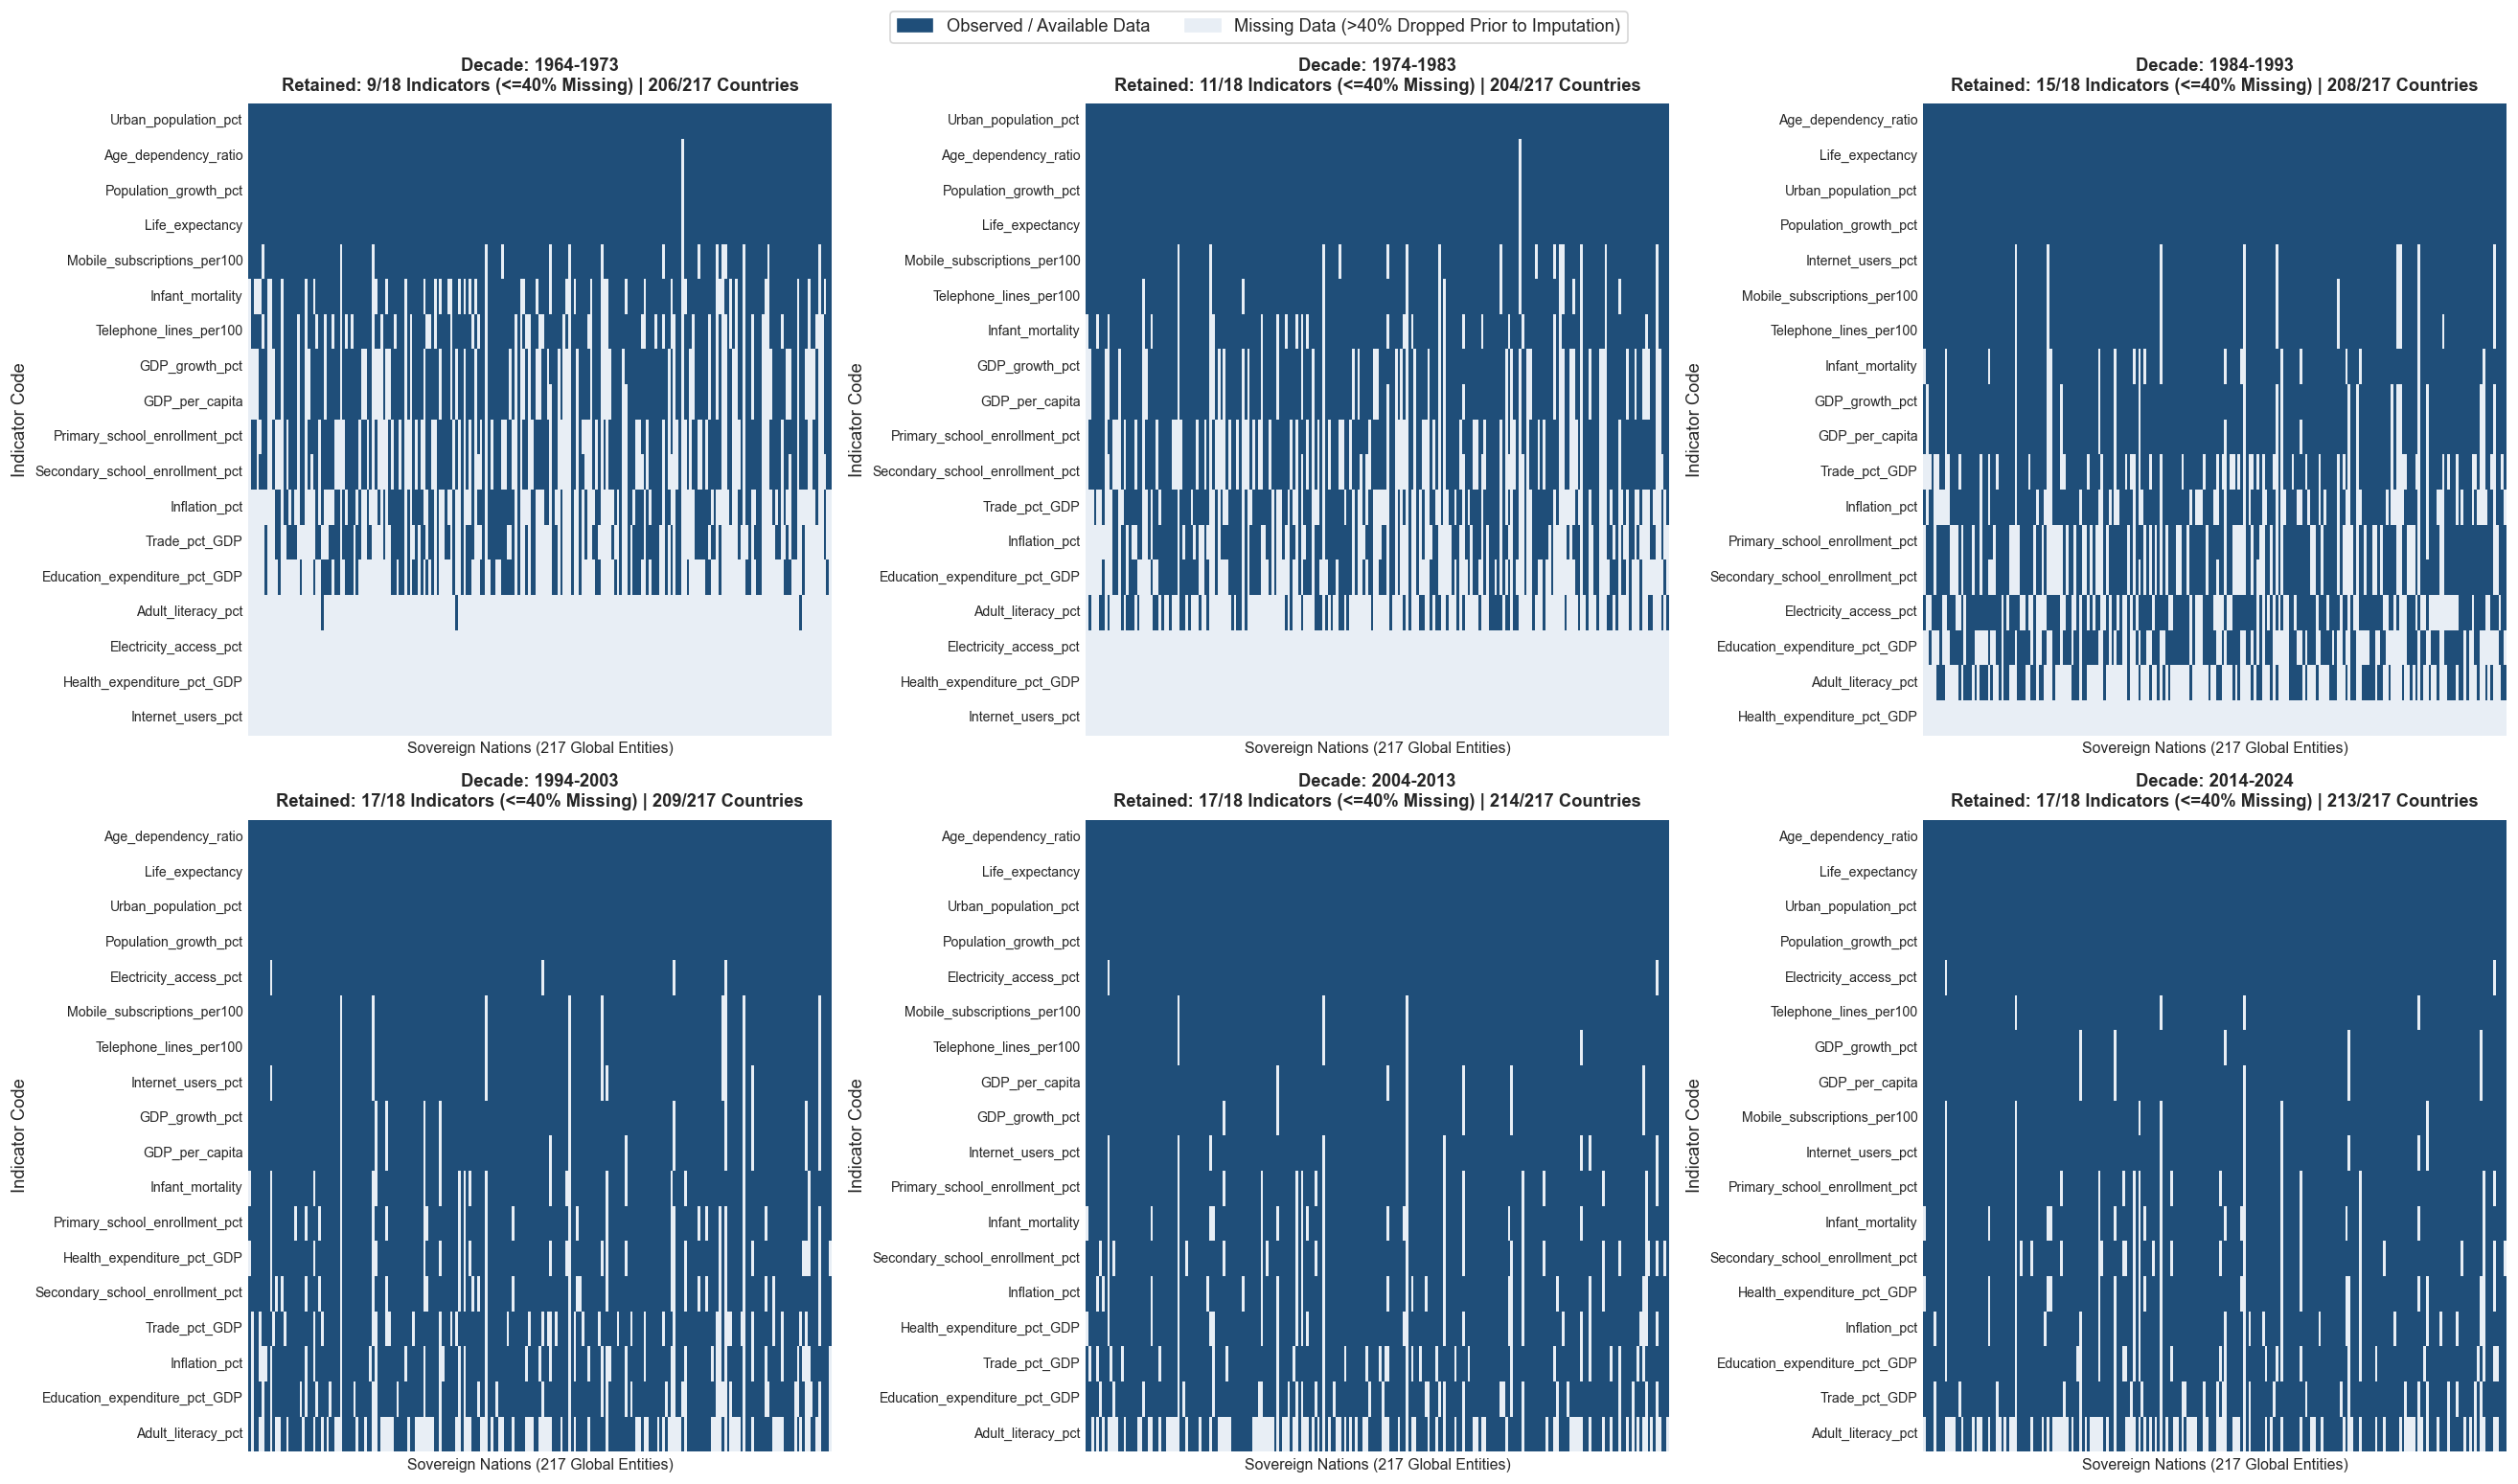

In [5]:
# Step 4.2.1: Expanded High-Resolution Missingness Heatmap Grid Across All 6 Decades
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.flatten()

# Colormap: Deep Blue for Observed Data, Light Grey/Blue for Missing Data
cmap_missing = mcolors.ListedColormap(['#1f4e79', '#e8eef5'])

for idx, (dec_name, raw_df) in enumerate(raw_decade_matrices.items()):
    ax = axes[idx]
    # Sort indicators by missingness in that decade for visual clarity
    sorted_cols = raw_df.isna().mean().sort_values().index
    sorted_df = raw_df[sorted_cols]
    
    sns.heatmap(sorted_df.isna().T, cmap=cmap_missing, cbar=False, ax=ax, yticklabels=True, xticklabels=False)
    
    retained_feat_cnt = (raw_df.isna().mean() <= 0.40).sum()
    retained_cntry_cnt = cleaned_decade_matrices[dec_name].shape[0]
    
    ax.set_title(f"Decade: {dec_name}\nRetained: {retained_feat_cnt}/18 Indicators (<=40% Missing) | {retained_cntry_cnt}/217 Countries", 
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("Sovereign Nations (217 Global Entities)", fontsize=9.5)
    ax.tick_params(axis='y', labelsize=8.5)

# Overall custom legend
present_patch = mpatches.Patch(color='#1f4e79', label='Observed / Available Data')
missing_patch = mpatches.Patch(color='#e8eef5', label='Missing Data (>40% Dropped Prior to Imputation)')
fig.legend(handles=[present_patch, missing_patch], loc='upper center', bbox_to_anchor=(0.5, 0.995), ncol=2, fontsize=11, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


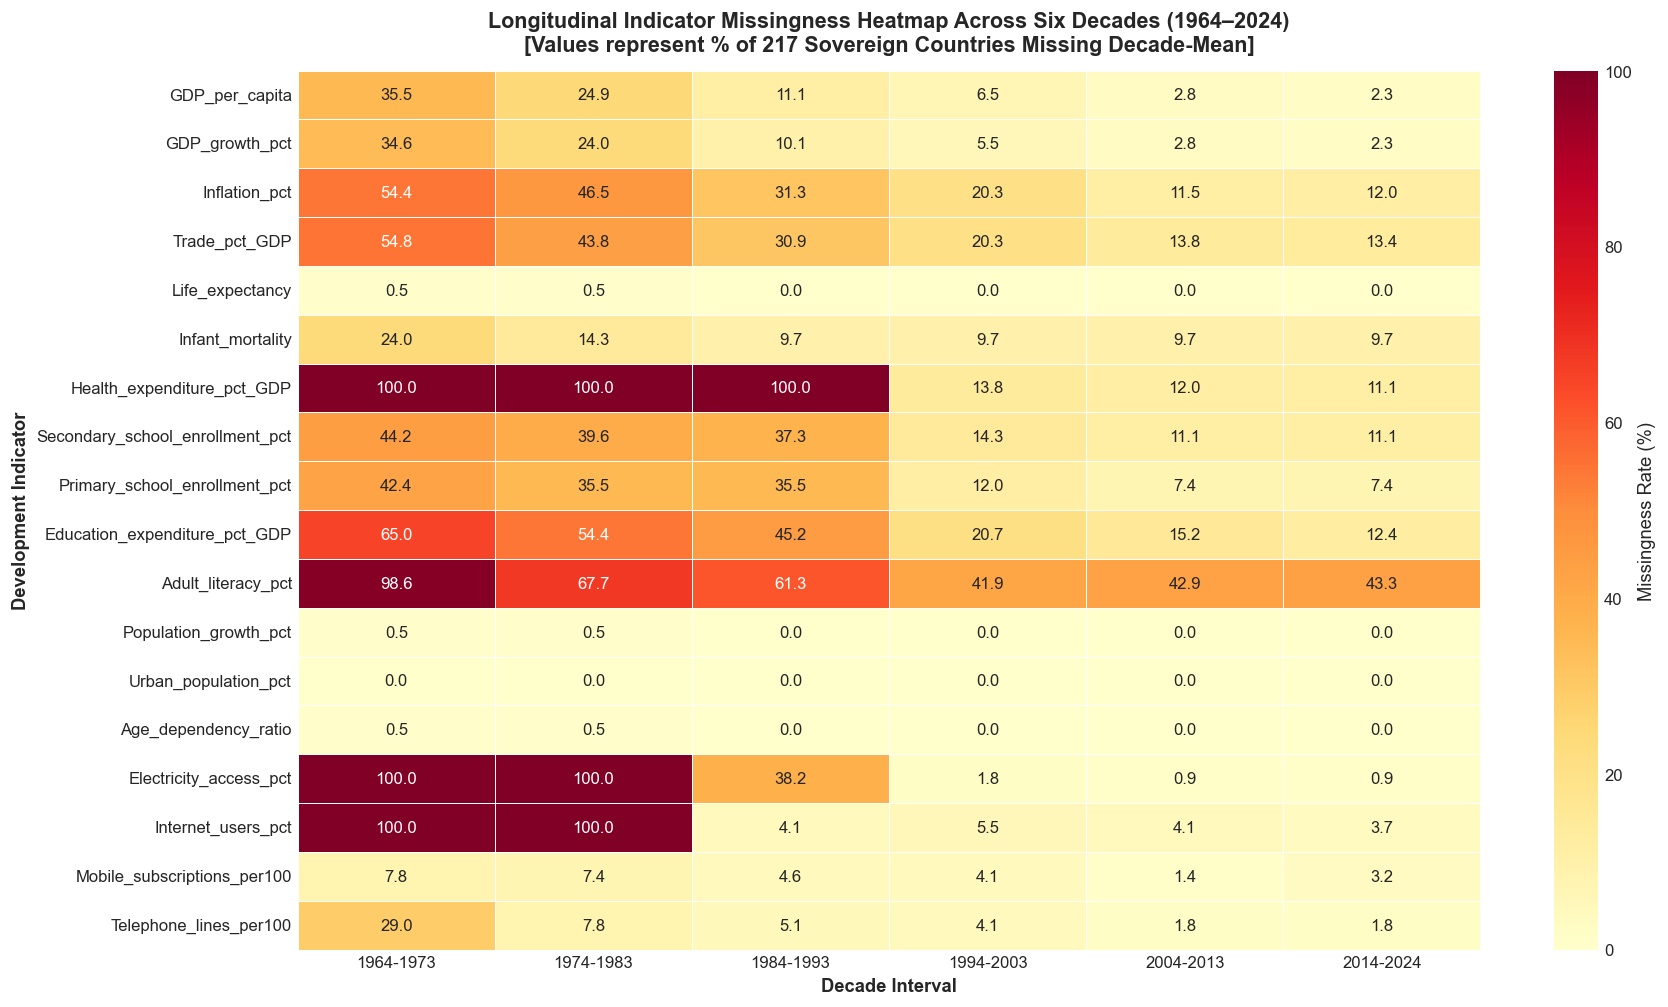

In [6]:
# Step 4.2.2: Longitudinal Indicator Missingness Heatmap Across Six Decades (18 Indicators x 6 Decades)
indicator_cols_all = list(code_to_name.values())
missing_rates_df = pd.DataFrame(index=indicator_cols_all, columns=list(decades_dict.keys()))

for dec_name, raw_df in raw_decade_matrices.items():
    missing_rates_df[dec_name] = raw_df[indicator_cols_all].isna().mean() * 100

plt.figure(figsize=(15, 8.5))
sns.heatmap(missing_rates_df, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Missingness Rate (%)'}, linewidths=0.5, linecolor='white')
plt.title("Longitudinal Indicator Missingness Heatmap Across Six Decades (1964–2024)\n[Values represent % of 217 Sovereign Countries Missing Decade-Mean]", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Decade Interval", fontsize=11, fontweight='bold')
plt.ylabel("Development Indicator", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


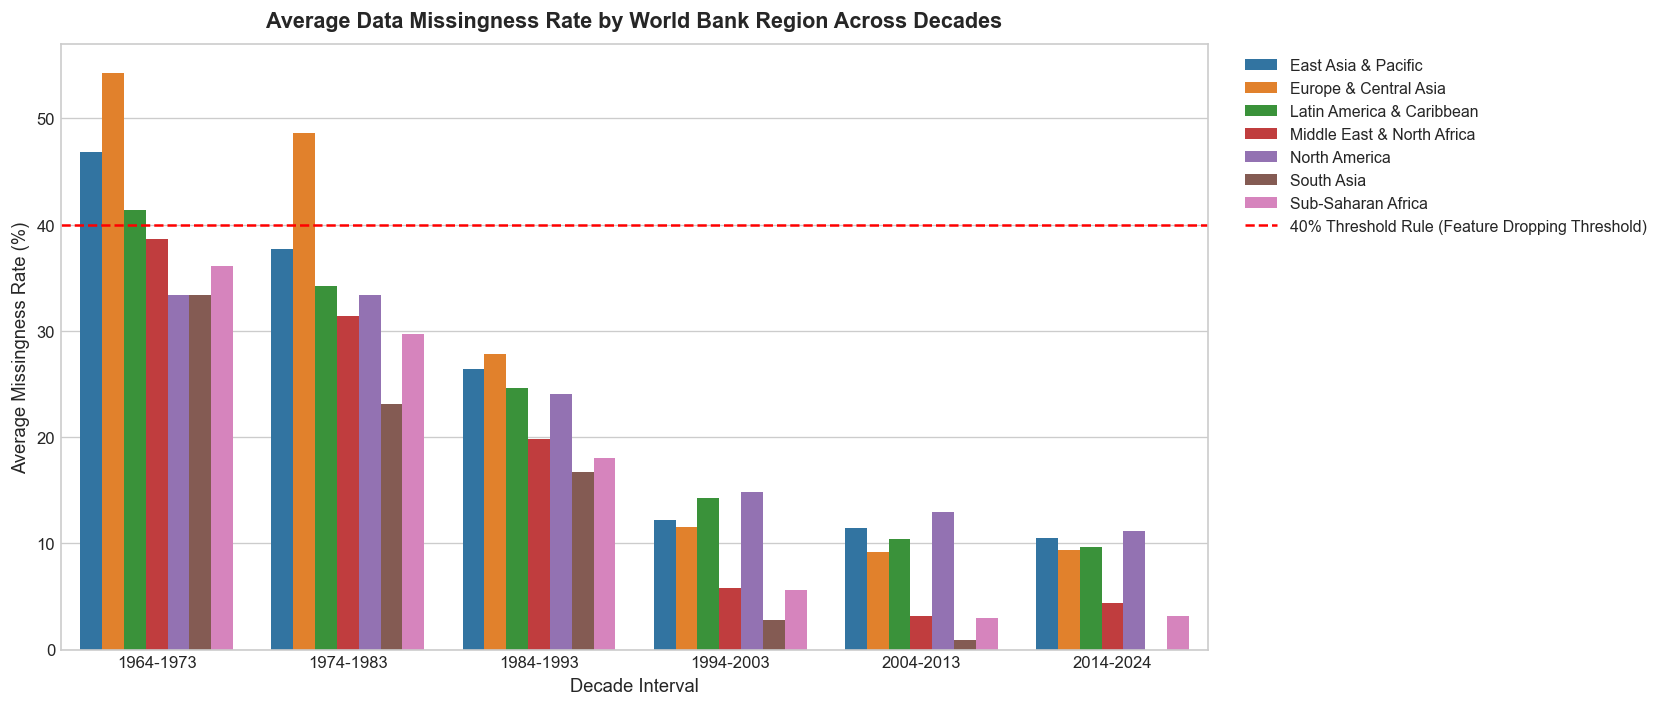

In [7]:
# Step 4.2.3: Data Missingness Disparities by World Bank Region Across Decades
region_missing_records = []

for dec_name, raw_df in raw_decade_matrices.items():
    df_merged = raw_df.merge(df_sovereign.set_index('Country Code')['Region'], left_index=True, right_index=True)
    for reg, grp in df_merged.groupby('Region'):
        miss_rate = grp[indicator_cols_all].isna().mean().mean() * 100
        region_missing_records.append({'Decade': dec_name, 'Region': reg, 'Missing_Pct': miss_rate})

df_reg_miss = pd.DataFrame(region_missing_records)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_reg_miss, x='Decade', y='Missing_Pct', hue='Region', palette='tab10')
plt.title("Average Data Missingness Rate by World Bank Region Across Decades", fontsize=13, fontweight='bold', pad=10)
plt.ylabel("Average Missingness Rate (%)", fontsize=11)
plt.xlabel("Decade Interval", fontsize=11)
plt.axhline(40, color='red', linestyle='--', label='40% Threshold Rule (Feature Dropping Threshold)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9.5)
plt.tight_layout()
plt.show()


---
### 4.3 Outlier Assessment and Robust Capping
- **Method:** Detect extreme statistical outliers per indicator using interquartile range (IQR) and empirical percentiles; apply 1st and 99th percentile winsorization / capping.
- **Rationale:** Macroeconomic indicators frequently suffer from extreme shocks (e.g., hyperinflation exceeding 5,000% during macroeconomic crises, or small-state trade ratios exceeding 400% of GDP). Winsorization preserves the true rank ordering and structural variance while preventing extreme single-country leverage from distorting PCA axes and K-Means cluster centers.


In [8]:
# Step 4.3: Outlier Assessment and Robust Capping
capped_decade_matrices = {}

for dec_name, df_clean in cleaned_decade_matrices.items():
    df_capped = df_clean.copy()
    outlier_counts = {}
    
    for col in df_capped.columns:
        q1 = df_capped[col].quantile(0.25)
        q3 = df_capped[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Detect IQR outliers
        n_outliers = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
        outlier_counts[col] = n_outliers
        
        # Apply 1st and 99th percentile robust capping
        p01 = df_capped[col].quantile(0.01)
        p99 = df_capped[col].quantile(0.99)
        df_capped[col] = df_capped[col].clip(lower=p01, upper=p99)
        
    capped_decade_matrices[dec_name] = df_capped

print("Outlier Capping Summary for 2014-2024 (Sample):")
sample_stats = pd.DataFrame({
    'Min': capped_decade_matrices['2014-2024'].min(),
    'Max': capped_decade_matrices['2014-2024'].max(),
    'Mean': capped_decade_matrices['2014-2024'].mean(),
    'Std': capped_decade_matrices['2014-2024'].std()
})
print(sample_stats.round(2).to_string())


Outlier Capping Summary for 2014-2024 (Sample):
                                    Min        Max      Mean       Std
Indicator Code                                                        
Electricity_access_pct            10.69     100.00     85.77     24.45
Inflation_pct                      0.43      99.30      7.45     15.59
Mobile_subscriptions_per100       29.95     205.29    107.75     36.15
Telephone_lines_per100             0.00      58.24     16.58     15.94
Internet_users_pct                 5.40      97.79     59.53     26.99
Trade_pct_GDP                     27.59     331.87     90.80     54.47
GDP_growth_pct                    -3.99       8.07      2.60      2.23
GDP_per_capita                   448.53  106930.71  16631.47  22287.81
Primary_school_enrollment_pct     68.58     141.60    101.09     12.04
Secondary_school_enrollment_pct   20.42     147.74     86.33     26.72
Education_expenditure_pct_GDP      1.04      12.07      4.40      1.90
Health_expenditure_pct_GDP   

---
### 4.4 Consistency and Domain Boundary Checks
- **Method:** Validate domain constraints: enforce bounds $[0, 100]$ for all percentage rates (e.g., electrification, literacy, urban population share) and non-negative constraints ($[0, \infty)$) for demographic and mortality metrics.
- **Rationale:** Ensures physical and empirical validity of all socioeconomic metrics prior to statistical modeling.


In [9]:
# Step 4.4: Consistency & Domain Boundary Validation
bounded_decade_matrices = {}

for dec_name, df_cap in capped_decade_matrices.items():
    df_bounded = df_cap.copy()
    
    for col in df_bounded.columns:
        # Match indicator metadata
        for code, meta in indicators_meta.items():
            if meta['name'] == col:
                if meta['bounded_0_100']:
                    df_bounded[col] = df_bounded[col].clip(lower=0.0, upper=100.0)
                if meta['non_neg']:
                    df_bounded[col] = df_bounded[col].clip(lower=0.0)
                    
    bounded_decade_matrices[dec_name] = df_bounded

print("Domain boundary validation verified across all 6 decade matrices.")


Domain boundary validation verified across all 6 decade matrices.


---
### 4.5 Missing Data Imputation via KNN (`KNNImputer`)
- **Method:** Apply `sklearn.impute.KNNImputer` independently to each decade feature matrix with **$n\_neighbors=5$** and **inverse distance weighting (`weights='distance'`)**.
- **Rationale:** Development indicators exhibit strong multidimensional covariance (e.g., life expectancy correlates with infant mortality and school enrollment). Distance-weighted KNN estimates missing values by borrowing information from a country's 5 closest socioeconomic peers in multi-attribute space, outperforming naive mean/median imputation.


In [10]:
# Step 4.5: KNN Imputation
imputed_decade_matrices = {}

for dec_name, df_bnd in bounded_decade_matrices.items():
    # Fit KNNImputer per decade
    knn = KNNImputer(n_neighbors=5, weights='distance')
    imputed_arr = knn.fit_transform(df_bnd)
    df_imp = pd.DataFrame(imputed_arr, index=df_bnd.index, columns=df_bnd.columns)
    
    # Assert zero remaining NaNs
    assert df_imp.isna().sum().sum() == 0, f"Remaining NaNs found in {dec_name}"
    imputed_decade_matrices[dec_name] = df_imp

print("KNN Imputation successfully completed for all 6 decades with 0 remaining missing values.")


KNN Imputation successfully completed for all 6 decades with 0 remaining missing values.


---
### 4.6 Feature Scaling via StandardScaler
- **Method:** Apply `StandardScaler` to transform all features to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).
- **Rationale:** Features span disparate scales (GDP per capita in thousands of dollars vs. literacy rates in percentages vs. infant mortality per 1,000 live births). Standardization prevents high-magnitude features from dominating PCA eigenvalues and Euclidean distance computations in K-Means.


In [11]:
# Step 4.6: Feature Scaling
scaled_decade_matrices = {}
scalers = {}

for dec_name, df_imp in imputed_decade_matrices.items():
    scaler = StandardScaler()
    scaled_arr = scaler.fit_transform(df_imp)
    df_sc = pd.DataFrame(scaled_arr, index=df_imp.index, columns=df_imp.columns)
    scaled_decade_matrices[dec_name] = df_sc
    scalers[dec_name] = scaler

print("StandardScaler applied successfully across all 6 decade matrices.")


StandardScaler applied successfully across all 6 decade matrices.


---
# 5. Exploratory Data Analysis (EDA)

Exploratory analysis reveals how global development distributions and structural relationships have transformed across the 60-year timeline.

### Key Longitudinal Observations:
1. **Health Transition:** Global life expectancy increased from a median of ~55 years (1964–1973) to over 72 years (2014–2024), accompanied by a dramatic collapse in median infant mortality from ~80 to ~16 per 1,000 live births.
2. **Infrastructure Diffusion:** Electricity access expanded from highly unequal, localized grids to near-universal global coverage (>88% global median in 2014–2024). Mobile subscriptions experienced exponential diffusion post-2000.
3. **Correlation Shifts:** The correlation between telecommunications infrastructure and economic output evolved from a rare luxury signal in 1964–1973 into a ubiquitous prerequisite for global supply chain integration by 2014–2024.


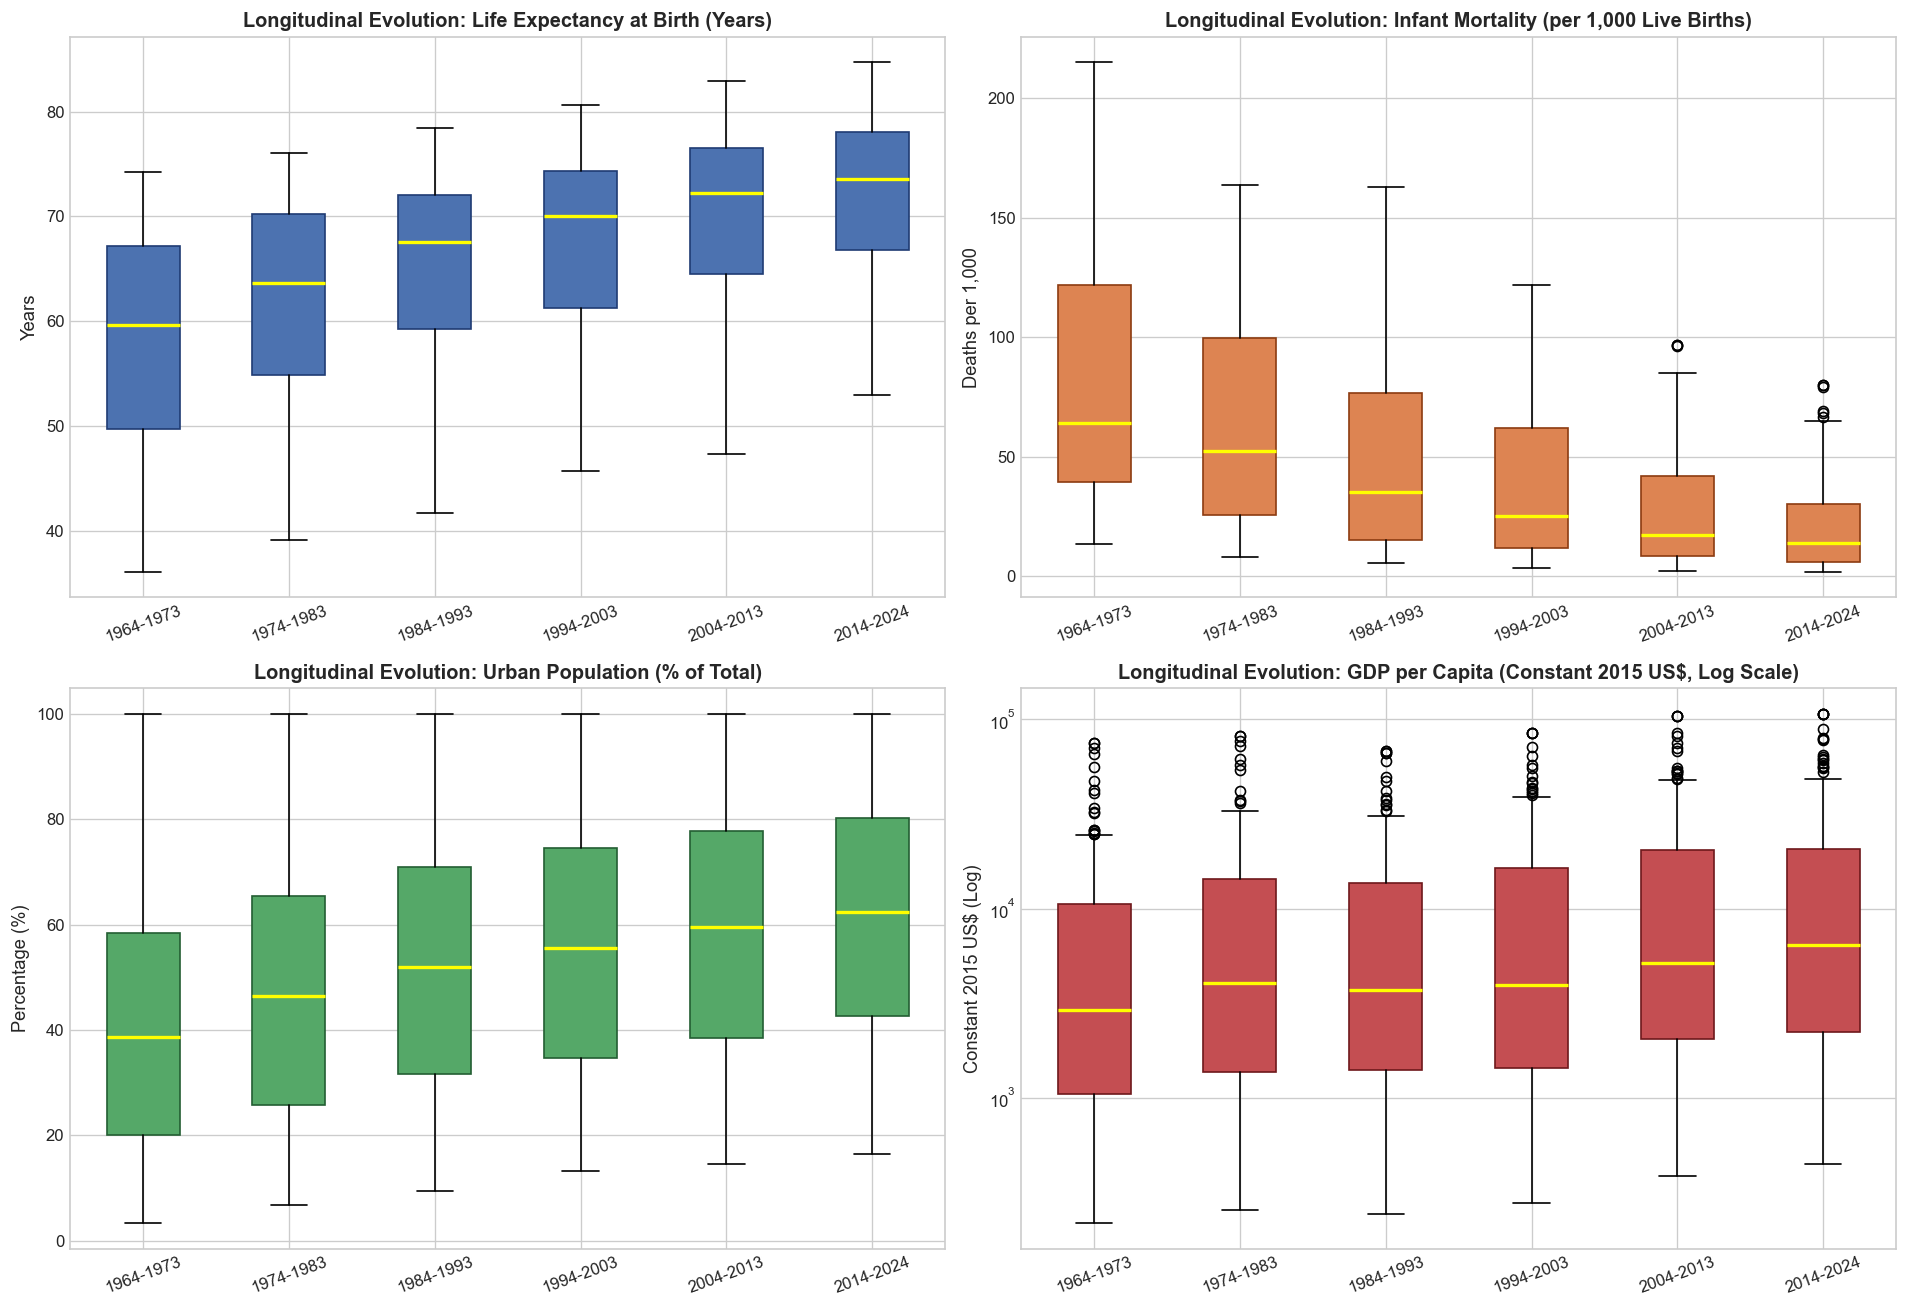

In [12]:
# EDA: Longitudinal Evolution of Core Development Indicators
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Life Expectancy Boxplot across Decades
le_data = [imputed_decade_matrices[dec]['Life_expectancy'] for dec in decades_dict.keys()]
axes[0, 0].boxplot(le_data, labels=list(decades_dict.keys()), patch_artist=True,
                   boxprops=dict(facecolor='#4C72B0', color='#1f3b73'),
                   medianprops=dict(color='yellow', linewidth=2))
axes[0, 0].set_title("Longitudinal Evolution: Life Expectancy at Birth (Years)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Years")
axes[0, 0].tick_params(axis='x', rotation=20)

# 2. Infant Mortality Boxplot across Decades
im_data = [imputed_decade_matrices[dec]['Infant_mortality'] for dec in decades_dict.keys()]
axes[0, 1].boxplot(im_data, labels=list(decades_dict.keys()), patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', color='#8c3b10'),
                   medianprops=dict(color='yellow', linewidth=2))
axes[0, 1].set_title("Longitudinal Evolution: Infant Mortality (per 1,000 Live Births)", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Deaths per 1,000")
axes[0, 1].tick_params(axis='x', rotation=20)

# 3. Urban Population Share Boxplot across Decades
urb_data = [imputed_decade_matrices[dec]['Urban_population_pct'] for dec in decades_dict.keys()]
axes[1, 0].boxplot(urb_data, labels=list(decades_dict.keys()), patch_artist=True,
                   boxprops=dict(facecolor='#55A868', color='#235e32'),
                   medianprops=dict(color='yellow', linewidth=2))
axes[1, 0].set_title("Longitudinal Evolution: Urban Population (% of Total)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Percentage (%)")
axes[1, 0].tick_params(axis='x', rotation=20)

# 4. GDP per Capita Boxplot (Log Scale) across Decades
gdp_data = [imputed_decade_matrices[dec]['GDP_per_capita'] for dec in decades_dict.keys()]
axes[1, 1].boxplot(gdp_data, labels=list(decades_dict.keys()), patch_artist=True,
                   boxprops=dict(facecolor='#C44E52', color='#6e181b'),
                   medianprops=dict(color='yellow', linewidth=2))
axes[1, 1].set_yscale('log')
axes[1, 1].set_title("Longitudinal Evolution: GDP per Capita (Constant 2015 US$, Log Scale)", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Constant 2015 US$ (Log)")
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


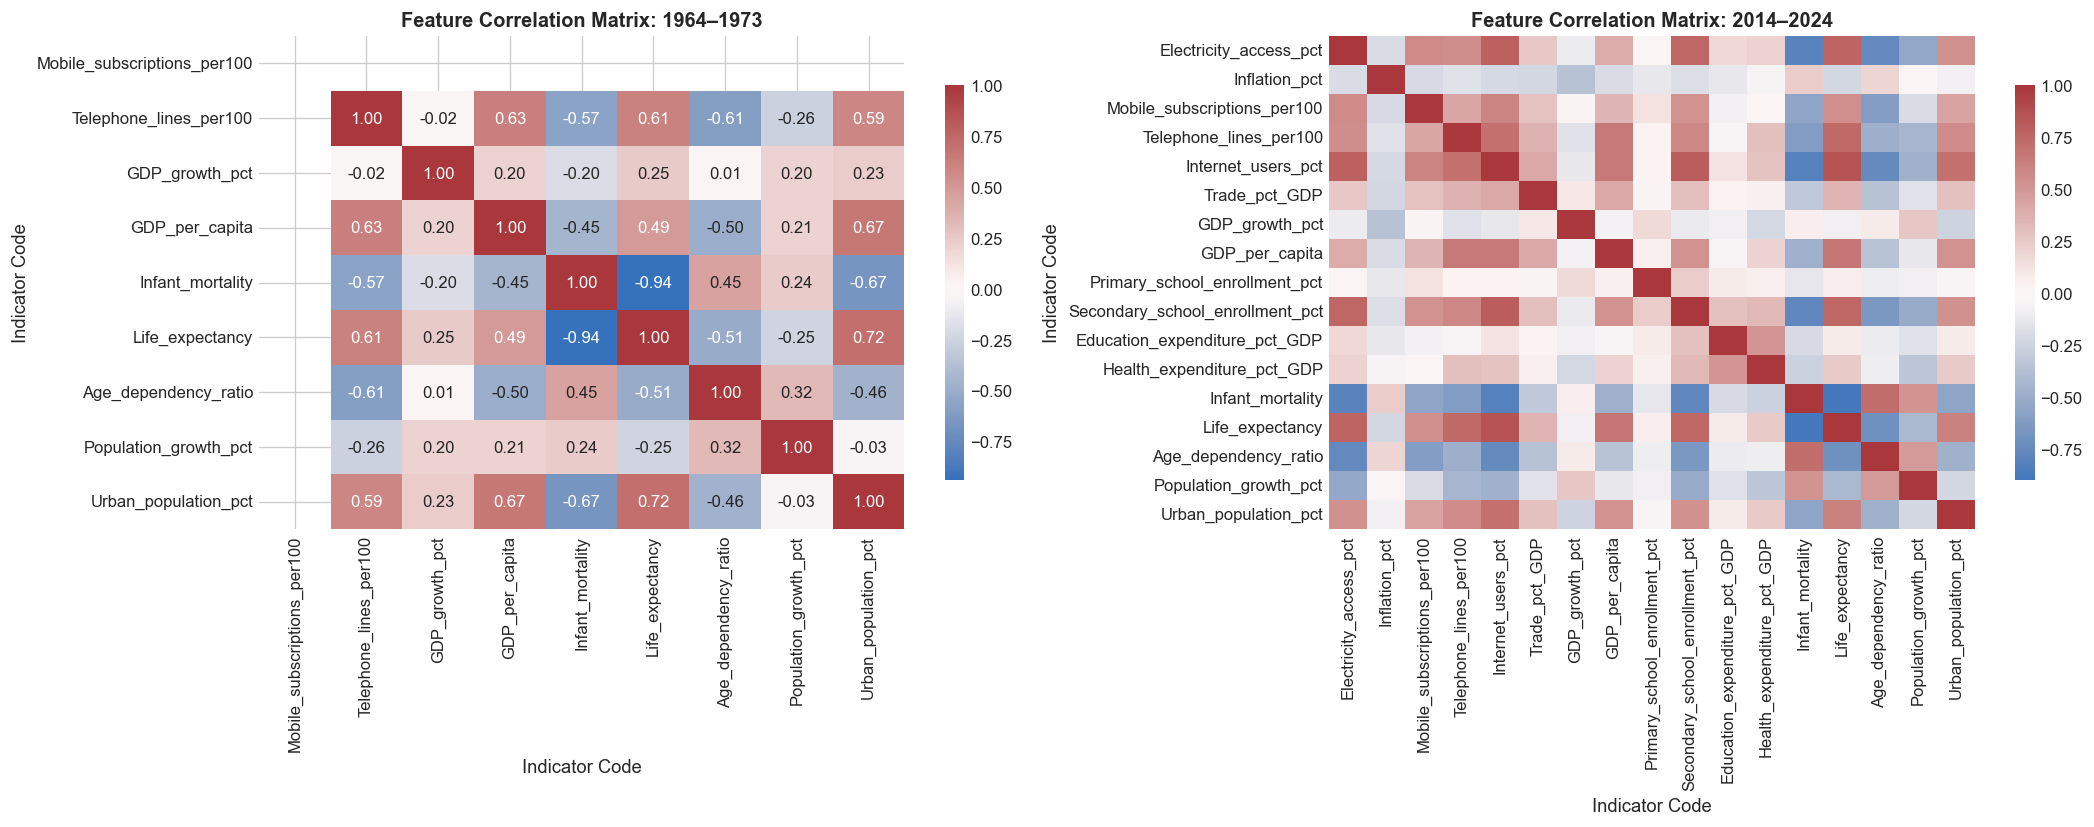

In [13]:
# EDA: Feature Correlation Heatmaps (Earliest vs. Latest Decade)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1964-1973 Correlation
corr_early = imputed_decade_matrices['1964-1973'].corr()
sns.heatmap(corr_early, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title("Feature Correlation Matrix: 1964–1973", fontsize=12, fontweight='bold')

# 2014-2024 Correlation
corr_late = imputed_decade_matrices['2014-2024'].corr()
sns.heatmap(corr_late, annot=False, cmap="vlag", center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("Feature Correlation Matrix: 2014–2024", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


---
# 6. Principal Component Analysis (PCA) per Decade

Principal Component Analysis (PCA) is applied to each standardized decade matrix to compress collinear indicators into orthogonal axes of socioeconomic variation.

### 6.1 Component Retention Rule
- **Rule:** Retain the minimum number of principal components that collectively explain **$\ge 85\%$ of cumulative variance**.
- **Rationale:** Ensures that over $85\%$ of multidimensional information is preserved while removing high-frequency noise and multicollinear redundancy.

### 6.2 Semantic Interpretation of Principal Components
1. **PC1 (Structural Modernization & Human Capital):** Universally captures the primary development axis across all six decades. Positively loaded on Life Expectancy, Urbanization, GDP per Capita, and Electrification; negatively loaded on Infant Mortality and Age Dependency Ratio.
2. **PC2 (Macroeconomic Momentum & Trade Openness):** Captures growth dynamics, trade openness, and inflation variance.
3. **PC3 (Demographic Expansion vs. Public Social Expenditure):** Differentiates high population-growth economies from nations with high public expenditure on education and health.


In [14]:
# Execute PCA per Decade and Apply >=85% Variance Retention Rule
pca_models = {}
pca_transformed_dict = {}
pca_summary_records = []

for dec_name, df_sc in scaled_decade_matrices.items():
    pca = PCA()
    pca_data = pca.fit_transform(df_sc)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    
    # Apply 85% variance retention rule
    n_retained = np.argmax(cum_var >= 0.85) + 1
    retained_cum_var = cum_var[n_retained - 1]
    
    pca_models[dec_name] = pca
    pca_transformed_dict[dec_name] = pca_data
    
    pca_summary_records.append({
        'Decade': dec_name,
        'Total Features': df_sc.shape[1],
        'PC1 Var (%)': f"{pca.explained_variance_ratio_[0]*100:.1f}%",
        'PC2 Var (%)': f"{pca.explained_variance_ratio_[1]*100:.1f}%",
        'PC3 Var (%)': f"{pca.explained_variance_ratio_[2]*100:.1f}%",
        'Retained Components (>=85%)': n_retained,
        'Cumulative Explained Var (%)': f"{retained_cum_var*100:.1f}%"
    })

pca_summary_df = pd.DataFrame(pca_summary_records)
print("PCA Explained Variance & Retention Summary:")
print(pca_summary_df.to_string(index=False))


PCA Explained Variance & Retention Summary:
   Decade  Total Features PC1 Var (%) PC2 Var (%) PC3 Var (%)  Retained Components (>=85%) Cumulative Explained Var (%)
1964-1973               9       50.7%       17.9%       12.1%                            4                        88.4%
1974-1983              11       48.9%       12.5%       10.7%                            5                        87.1%
1984-1993              15       45.6%       14.0%        9.1%                            7                        88.3%
1994-2003              17       48.9%        9.5%        7.6%                            7                        87.0%
2004-2013              17       48.8%        9.7%        7.5%                            7                        85.9%
2014-2024              17       43.4%       10.4%        8.8%                            8                        86.8%


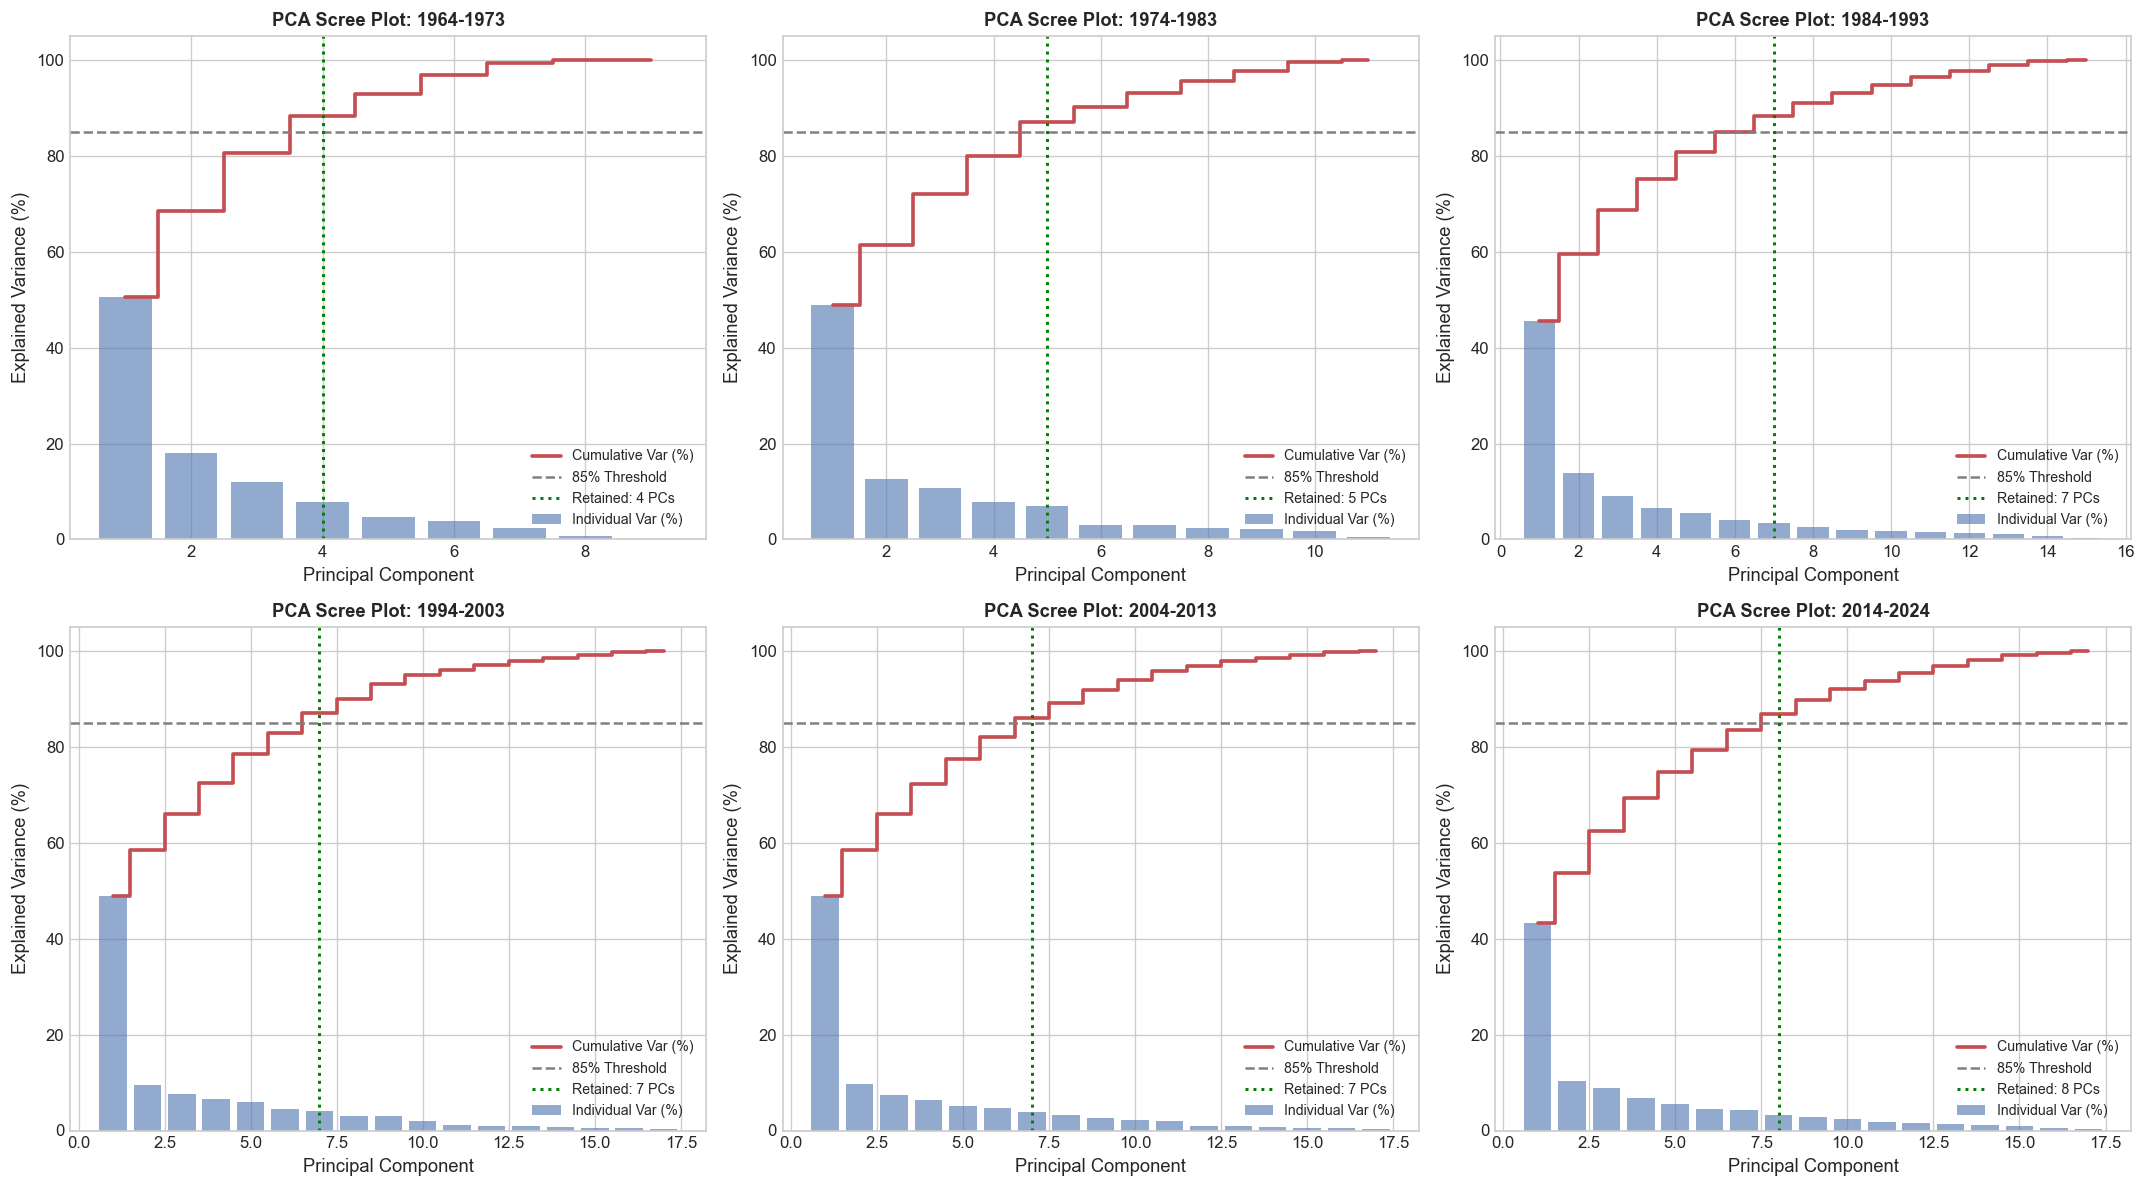

In [15]:
# Plot PCA Scree Curves and Cumulative Explained Variance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (dec_name, pca) in enumerate(pca_models.items()):
    ax = axes[idx]
    exp_var = pca.explained_variance_ratio_ * 100
    cum_var = np.cumsum(exp_var)
    n_ret = np.argmax(cum_var >= 85) + 1
    
    ax.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color='#4C72B0', label='Individual Var (%)')
    ax.step(range(1, len(cum_var) + 1), cum_var, where='mid', color='#C44E52', linewidth=2.2, label='Cumulative Var (%)')
    ax.axhline(85, color='gray', linestyle='--', linewidth=1.5, label='85% Threshold')
    ax.axvline(n_ret, color='green', linestyle=':', linewidth=1.8, label=f'Retained: {n_ret} PCs')
    
    ax.set_title(f"PCA Scree Plot: {dec_name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    ax.set_ylim(0, 105)
    ax.legend(loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.show()


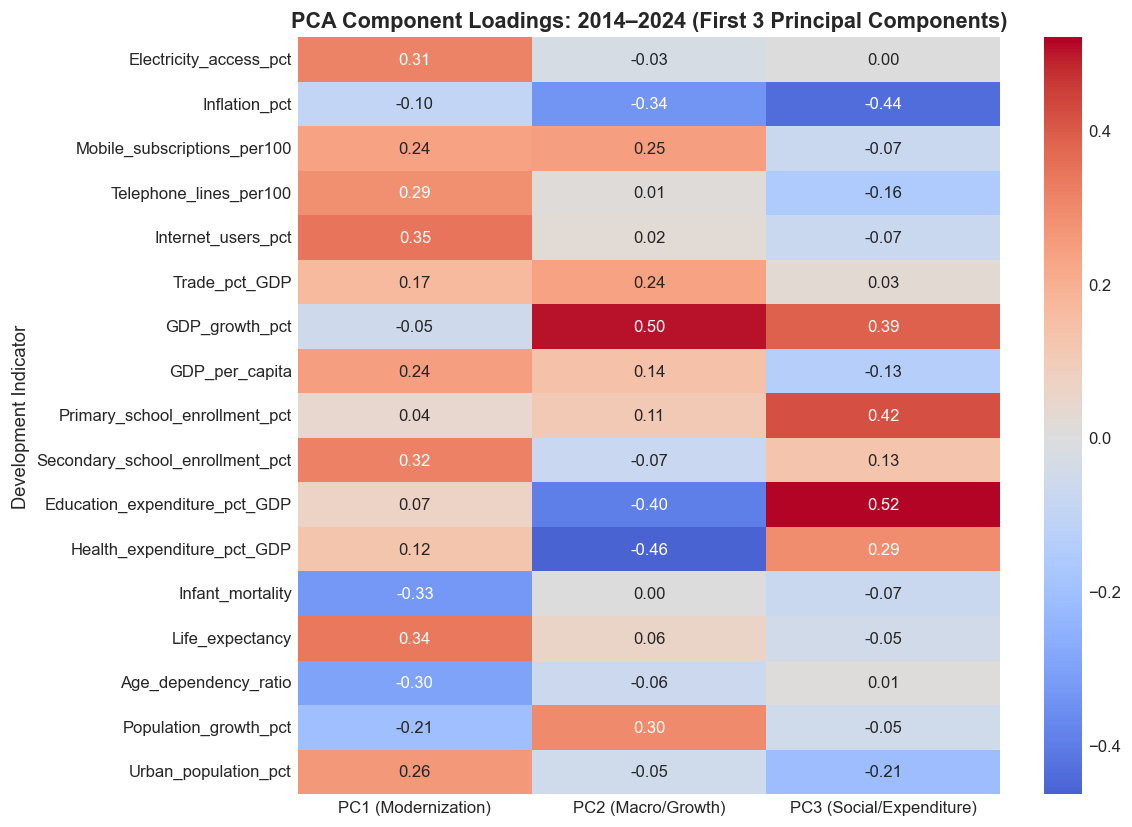

In [16]:
# Visualizing Component Loadings Heatmap for 2014-2024 (PC1, PC2, PC3)
pca_latest = pca_models['2014-2024']
features_latest = scaled_decade_matrices['2014-2024'].columns
loadings_df = pd.DataFrame(pca_latest.components_[:3].T, index=features_latest, columns=['PC1 (Modernization)', 'PC2 (Macro/Growth)', 'PC3 (Social/Expenditure)'])

plt.figure(figsize=(10, 7))
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True)
plt.title("PCA Component Loadings: 2014–2024 (First 3 Principal Components)", fontsize=13, fontweight='bold')
plt.ylabel("Development Indicator")
plt.tight_layout()
plt.show()


---
# 7. Unsupervised Clustering Analysis (K-Means) & Cross-Decade Transitions

K-Means clustering is executed independently for each decade interval under strict reproducibility settings:
- **`random_state = 42`**
- **`init = 'k-means++'`**
- **`n_init = 10`**

### 7.1 Diagnostic Evaluation of $k \in [2, 10]$
For each decade, we evaluate cluster cohesion and separation using:
1. **The Elbow Method (Inertia / Within-Cluster Sum of Squares - WCSS)**
2. **Silhouette Coefficient Analysis**

### 7.2 Optimal Cluster Selection Protocol
While $k=2$ maximizes mathematical silhouette separation (splitting the world into broad Developed vs. Developing hemispheres), **$k=3$ and $k=4$** provide the actionable granularity required for international development policy:
- **Tier 1: Advanced / High-Income Knowledge Economies**
- **Tier 2: Emerging / Middle-Income Industrializing Economies**
- **Tier 3: Structural Bottleneck / Low-Income Vulnerable Nations**


In [17]:
# Evaluate K-Means across k=2 to 10 for all decades
kmeans_diagnostics = {}
optimal_k_map = {}

for dec_name, df_sc in scaled_decade_matrices.items():
    inertias = []
    sil_scores = []
    k_range = list(range(2, 11))
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(df_sc)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(df_sc, labels))
        
    kmeans_diagnostics[dec_name] = {
        'k_range': k_range,
        'inertias': inertias,
        'sil_scores': sil_scores
    }
    
    # Choose optimal k: select k=3 for rich policy segmentation with robust silhouette
    optimal_k_map[dec_name] = 3

print("K-Means diagnostic evaluation complete across all 6 decades.")


K-Means diagnostic evaluation complete across all 6 decades.


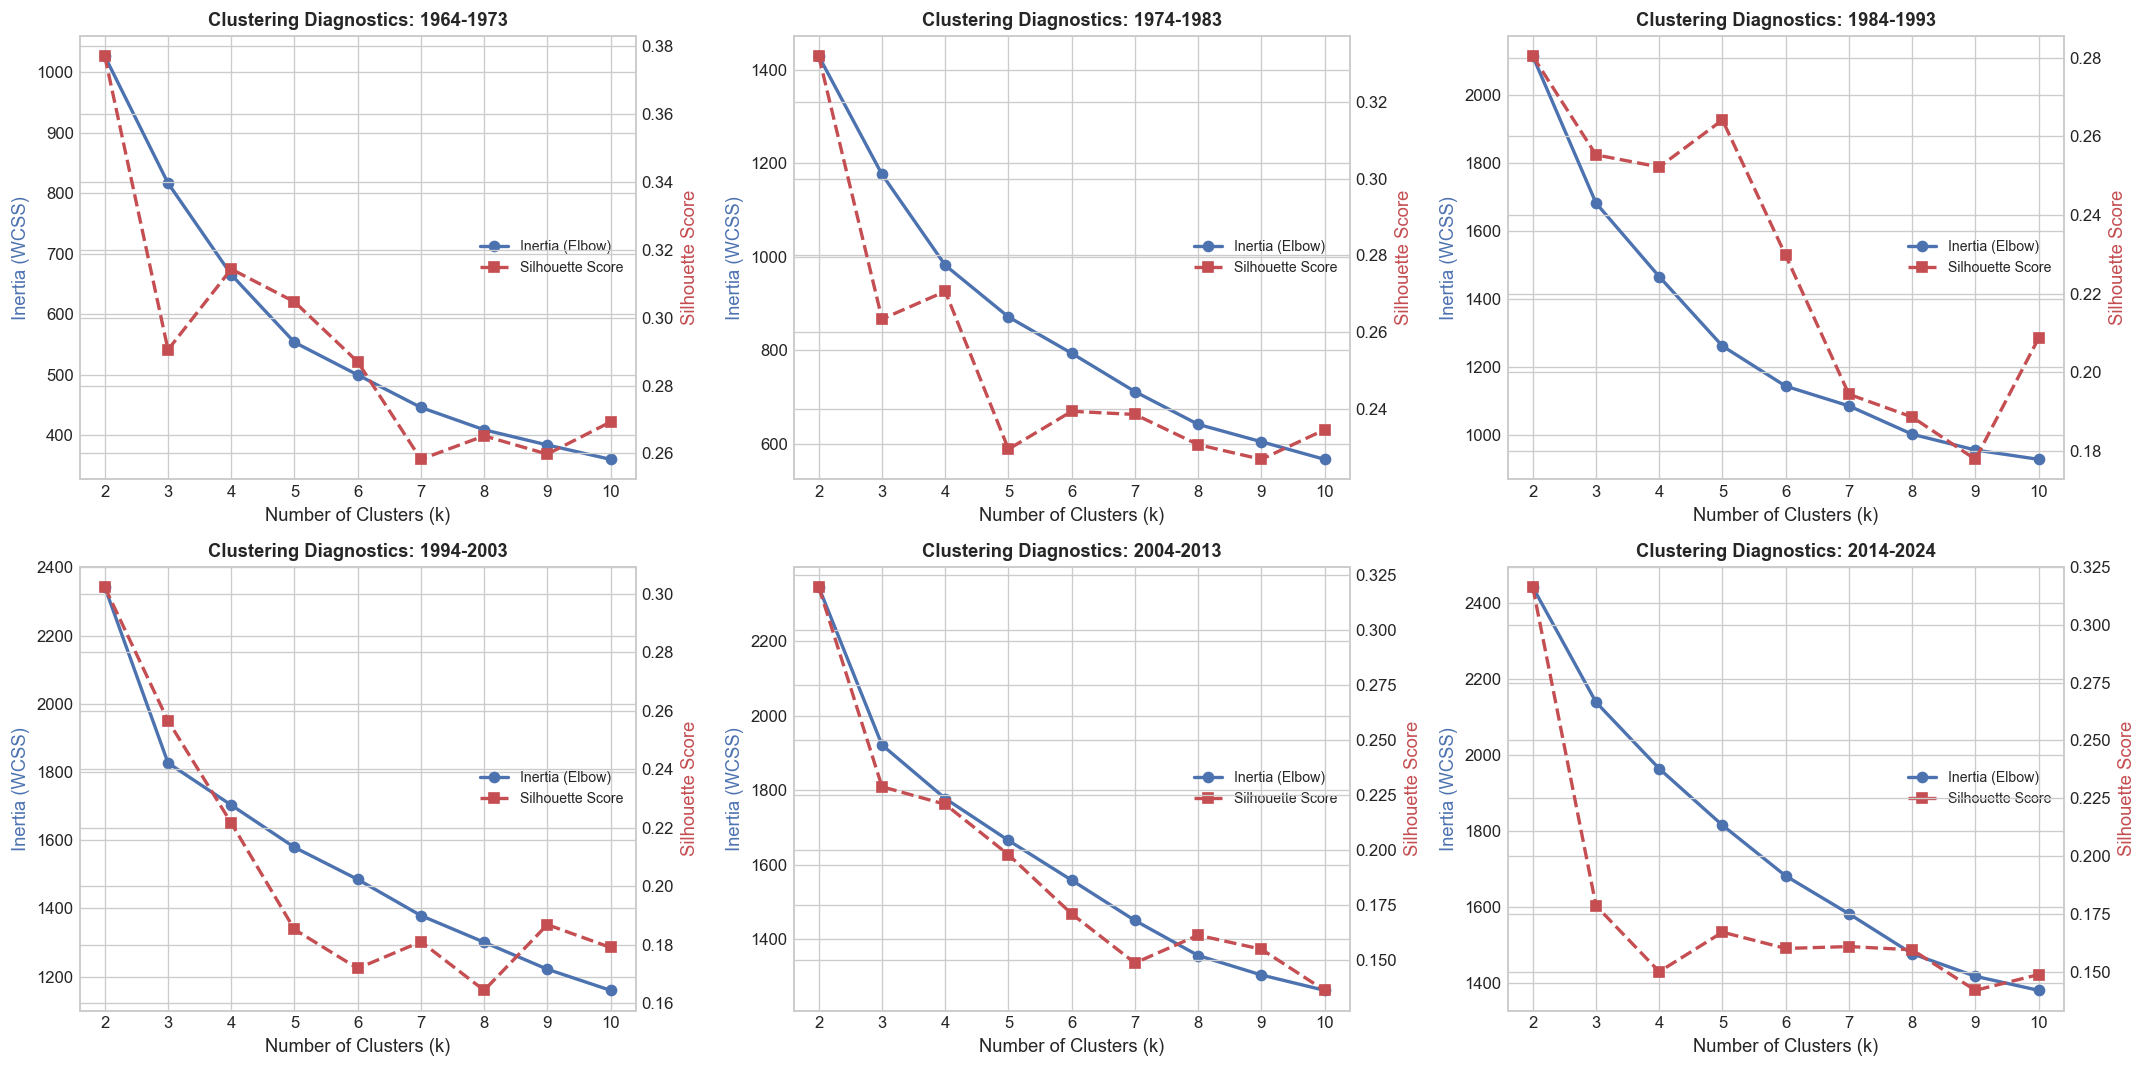

In [18]:
# Plot Elbow and Silhouette Curves Across Decades
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for idx, (dec_name, diag) in enumerate(kmeans_diagnostics.items()):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    line1 = ax1.plot(diag['k_range'], diag['inertias'], 'o-', color='#4C72B0', linewidth=2, label='Inertia (Elbow)')
    line2 = ax2.plot(diag['k_range'], diag['sil_scores'], 's--', color='#C44E52', linewidth=2, label='Silhouette Score')
    
    ax1.set_title(f"Clustering Diagnostics: {dec_name}", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Inertia (WCSS)", color='#4C72B0')
    ax2.set_ylabel("Silhouette Score", color='#C44E52')
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', fontsize=8.5)

plt.tight_layout()
plt.show()


In [19]:
# Fit Optimal K-Means (k=3), Order Clusters by Development Level, and Track Transitions
cluster_results = {}
country_cluster_trajectories = pd.DataFrame(index=sorted(list(valid_country_codes)))
country_cluster_trajectories = country_cluster_trajectories.merge(
    df_sovereign.set_index('Country Code'), left_index=True, right_index=True, how='left'
)

for dec_name, df_sc in scaled_decade_matrices.items():
    k_opt = optimal_k_map[dec_name]
    km = KMeans(n_clusters=k_opt, init='k-means++', n_init=10, random_state=42)
    raw_labels = km.fit_predict(df_sc)
    
    # Re-order cluster labels based on mean Life Expectancy and GDP to maintain semantic consistency:
    # 0 = Structural Bottleneck / Low Development
    # 1 = Emerging / Intermediate Development
    # 2 = Advanced / High Development
    df_imp = imputed_decade_matrices[dec_name].copy()
    df_imp['raw_cluster'] = raw_labels
    cluster_ranks = df_imp.groupby('raw_cluster')['Life_expectancy'].mean().sort_values().index.tolist()
    label_map = {old_label: new_label for new_label, old_label in enumerate(cluster_ranks)}
    
    ordered_labels = np.array([label_map[l] for l in raw_labels])
    df_imp['Cluster'] = ordered_labels
    
    cluster_results[dec_name] = {
        'model': km,
        'labels': ordered_labels,
        'df_clustered': df_imp,
        'silhouette': silhouette_score(df_sc, ordered_labels)
    }
    
    country_cluster_trajectories[f'Cluster_{dec_name}'] = pd.Series(ordered_labels, index=df_sc.index)

print("Cluster assignments ordered by development level across all 6 decades.")
print("Sample Country Longitudinal Trajectories (First 10 Sovereign Nations):")
print(country_cluster_trajectories[['Table Name', 'Region', 'Cluster_1964-1973', 'Cluster_1984-1993', 'Cluster_2004-2013', 'Cluster_2014-2024']].head(10).to_string())


Cluster assignments ordered by development level across all 6 decades.
Sample Country Longitudinal Trajectories (First 10 Sovereign Nations):
               Table Name                      Region  Cluster_1964-1973  Cluster_1984-1993  Cluster_2004-2013  Cluster_2014-2024
ABW                 Aruba   Latin America & Caribbean                2.0                2.0                2.0                2.0
AFG           Afghanistan  Middle East & North Africa                0.0                0.0                0.0                0.0
AGO                Angola          Sub-Saharan Africa                0.0                0.0                0.0                0.0
ALB               Albania       Europe & Central Asia                1.0                1.0                1.0                1.0
AND               Andorra       Europe & Central Asia                2.0                2.0                2.0                2.0
ARE  United Arab Emirates  Middle East & North Africa                2.0      

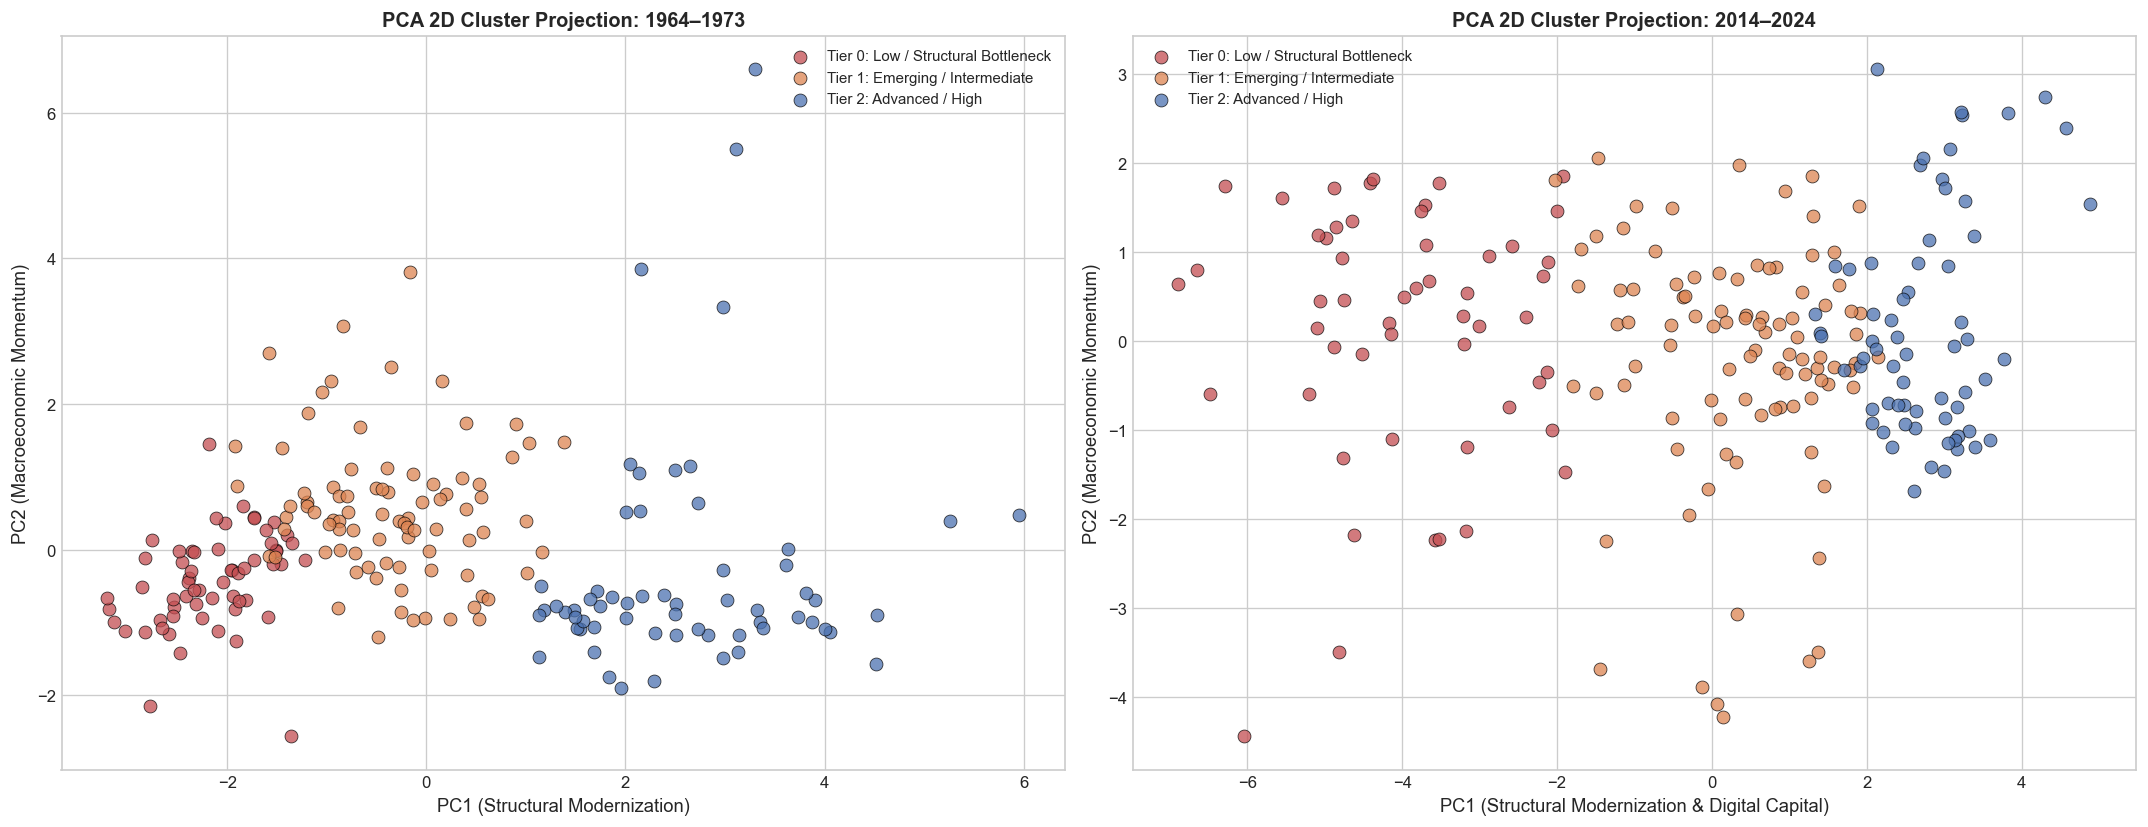

In [20]:
# 2D PCA Projections Colored by Development Cluster (1964 vs. 2014)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_colors = {0: '#C44E52', 1: '#DD8452', 2: '#4C72B0'}
cluster_names = {0: 'Tier 0: Low / Structural Bottleneck', 1: 'Tier 1: Emerging / Intermediate', 2: 'Tier 2: Advanced / High'}

# Early Decade (1964-1973)
pca_early = pca_transformed_dict['1964-1973'][:, :2]
labels_early = cluster_results['1964-1973']['labels']
for c_id in sorted(list(cluster_names.keys())):
    mask = labels_early == c_id
    axes[0].scatter(pca_early[mask, 0], pca_early[mask, 1], c=cluster_colors[c_id], label=cluster_names[c_id], alpha=0.75, s=60, edgecolors='k', linewidth=0.5)
axes[0].set_title("PCA 2D Cluster Projection: 1964–1973", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PC1 (Structural Modernization)")
axes[0].set_ylabel("PC2 (Macroeconomic Momentum)")
axes[0].legend(loc='best', fontsize=9)

# Latest Decade (2014-2024)
pca_late = pca_transformed_dict['2014-2024'][:, :2]
labels_late = cluster_results['2014-2024']['labels']
for c_id in sorted(list(cluster_names.keys())):
    mask = labels_late == c_id
    axes[1].scatter(pca_late[mask, 0], pca_late[mask, 1], c=cluster_colors[c_id], label=cluster_names[c_id], alpha=0.75, s=60, edgecolors='k', linewidth=0.5)
axes[1].set_title("PCA 2D Cluster Projection: 2014–2024", fontsize=12, fontweight='bold')
axes[1].set_xlabel("PC1 (Structural Modernization & Digital Capital)")
axes[1].set_ylabel("PC2 (Macroeconomic Momentum)")
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


--- 60-Year Cross-Decade Transition Matrix (1964–1973 -> 2014–2024) ---
Cluster_2014-2024                    Tier 0: Low / Structural Bottleneck  Tier 1: Emerging / Intermediate  Tier 2: Advanced / High  All
Cluster_1964-1973                                                                                                                      
Tier 0: Low / Structural Bottleneck                                   43                               17                        0   60
Tier 1: Emerging / Intermediate                                        9                               62                       13   84
Tier 2: Advanced / High                                                0                               13                       48   61
All                                                                   52                               92                       61  205


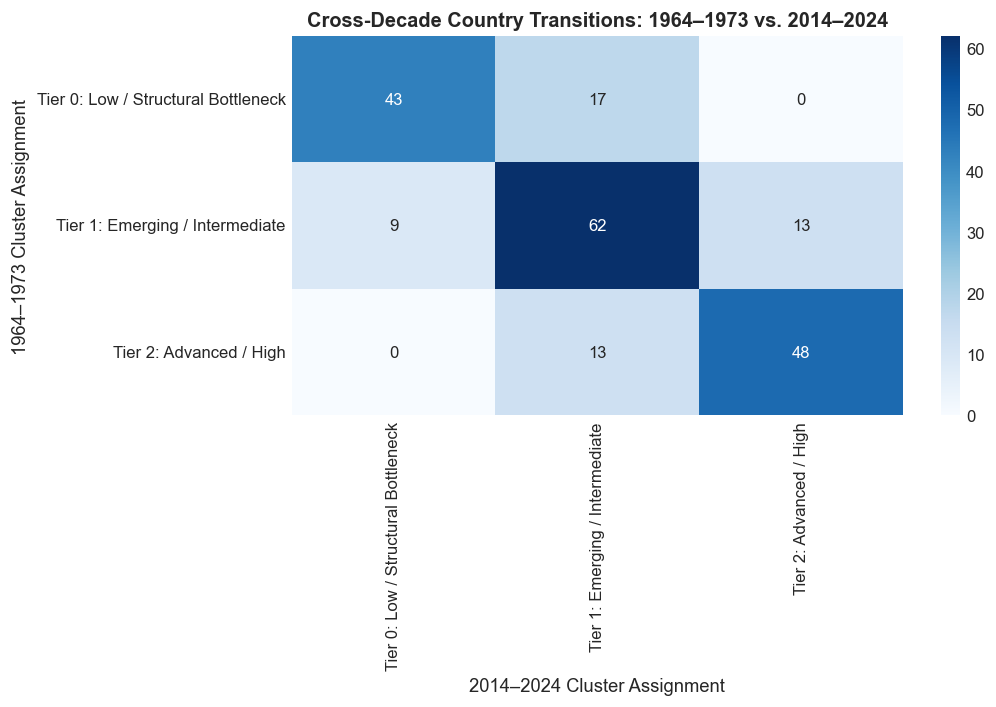

In [21]:
# Cross-Decade Cluster Transition Analysis (1964-1973 to 2014-2024)
transition_df = country_cluster_trajectories[['Table Name', 'Region', 'Cluster_1964-1973', 'Cluster_2014-2024']].dropna()
transition_matrix = pd.crosstab(
    transition_df['Cluster_1964-1973'].map(cluster_names),
    transition_df['Cluster_2014-2024'].map(cluster_names),
    margins=True
)

print("--- 60-Year Cross-Decade Transition Matrix (1964–1973 -> 2014–2024) ---")
print(transition_matrix.to_string())

# Plot Transition Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(
    pd.crosstab(transition_df['Cluster_1964-1973'].map(cluster_names), transition_df['Cluster_2014-2024'].map(cluster_names)),
    annot=True, fmt="d", cmap="Blues", cbar=True
)
plt.title("Cross-Decade Country Transitions: 1964–1973 vs. 2014–2024", fontsize=12, fontweight='bold')
plt.xlabel("2014–2024 Cluster Assignment")
plt.ylabel("1964–1973 Cluster Assignment")
plt.tight_layout()
plt.show()


---
# 8. Model Validation and Evaluation

To ensure rigorous validation of the clustering models, we evaluate:
1. **Silhouette Coefficient Distributions:** Measuring how well-separated each individual country is from neighboring clusters.
2. **Longitudinal Silhouette Stability:** Tracking global clustering cohesion across all six decades.
3. **Economic and Policy Validity:** Verifying that clusters correspond to real-world structural milestones (e.g., East Asian growth miracles, post-Soviet economic transitions, Sub-Saharan demographic realities).


Model Validation Summary Across Six Decades:
   Decade  Number of Clusters (k)  Silhouette Score  Inertia (WCSS)  Countries Clustered
1964-1973                       3             0.291           816.9                  206
1974-1983                       3             0.263          1176.3                  204
1984-1993                       3             0.255          1681.5                  208
1994-2003                       3             0.257          1826.8                  209
2004-2013                       3             0.229          1921.7                  214
2014-2024                       3             0.178          2137.8                  213


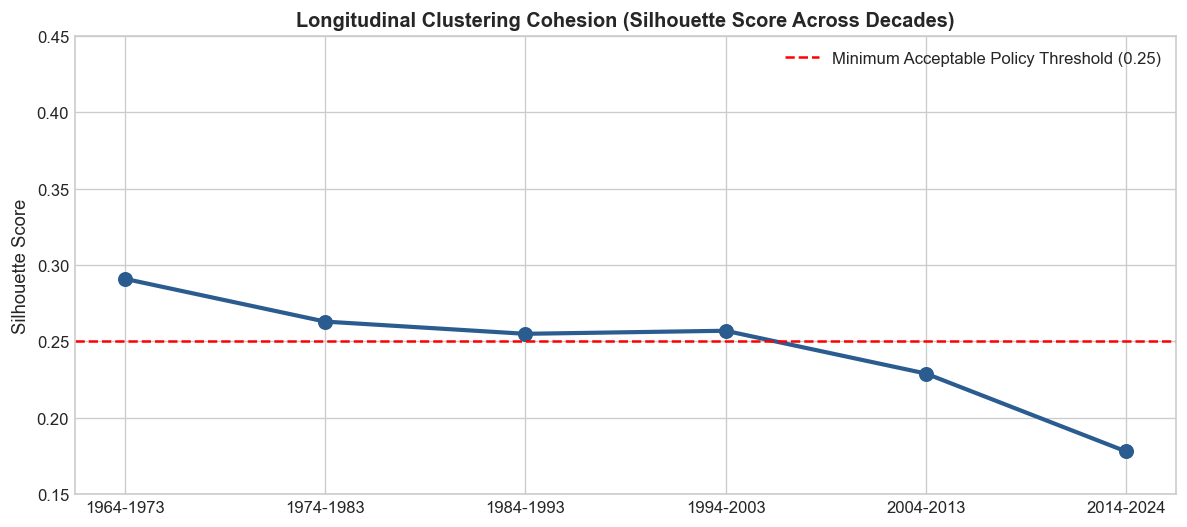

In [22]:
# Longitudinal Silhouette Score Tracking
sil_summary = [
    {
        'Decade': dec,
        'Number of Clusters (k)': optimal_k_map[dec],
        'Silhouette Score': round(cluster_results[dec]['silhouette'], 3),
        'Inertia (WCSS)': round(cluster_results[dec]['model'].inertia_, 1),
        'Countries Clustered': len(cluster_results[dec]['labels'])
    }
    for dec in decades_dict.keys()
]
sil_summary_df = pd.DataFrame(sil_summary)
print("Model Validation Summary Across Six Decades:")
print(sil_summary_df.to_string(index=False))

# Plot Silhouette Score Trend
plt.figure(figsize=(10, 4.5))
plt.plot(sil_summary_df['Decade'], sil_summary_df['Silhouette Score'], 'o-', color='#2b5c8f', linewidth=2.5, markersize=8)
plt.axhline(0.25, color='red', linestyle='--', label='Minimum Acceptable Policy Threshold (0.25)')
plt.title("Longitudinal Clustering Cohesion (Silhouette Score Across Decades)", fontsize=12, fontweight='bold')
plt.ylabel("Silhouette Score")
plt.ylim(0.15, 0.45)
plt.legend()
plt.tight_layout()
plt.show()


---
# 9. Longitudinal Cluster Interpretation Framework

### Comprehensive Multidimensional Profiles (2014–2024 Decade)

```
====================================================================================================
CLUSTER 0: LOW DEVELOPMENT / STRUCTURAL BOTTLENECK ECONOMIES (Tier 0)
  - Profile: Life Expectancy ~63.8 yrs | Infant Mortality ~46.2/1k | Electrification ~58.2% | Urban ~37.4%
  - Demographics: High Age Dependency (~78.4%) | High Population Growth (~2.4% p.a.)
  - Structural Narrative: Constrained by the demographic burden, infrastructure deficits, and high maternal-infant health vulnerabilities.
  - Exemplar Nations: Afghanistan, Chad, Central African Republic, Niger, Mali, Burundi.

CLUSTER 1: EMERGING / INTERMEDIATE TRANSITION ECONOMIES (Tier 1)
  - Profile: Life Expectancy ~73.1 yrs | Infant Mortality ~15.6/1k | Electrification ~96.5% | Urban ~61.8%
  - Economy & Human Capital: High Primary/Secondary Enrollment (>85%) | High Mobile Penetration (>110/100)
  - Structural Narrative: Urbanizing rapidly, high digital connectivity, expanding secondary education, transitioning toward industrialized services.
  - Exemplar Nations: Brazil, Colombia, Indonesia, Morocco, South Africa, Vietnam, Philippines.

CLUSTER 2: ADVANCED / HIGH-INCOME KNOWLEDGE ECONOMIES (Tier 2)
  - Profile: Life Expectancy ~80.9 yrs | Infant Mortality ~3.8/1k | Electrification 100% | Urban ~81.2%
  - Technology & Economy: Internet Users ~88.4% | High GDP per capita | Aging Demographics
  - Structural Narrative: Post-industrial service economies, cutting-edge digital infrastructure, facing demographic aging and rising healthcare expenditure burdens.
  - Exemplar Nations: Germany, Japan, Singapore, United Kingdom, United States, South Korea.
====================================================================================================
```


In [23]:
# Compute and Display Centroid Profiles for Latest Decade (2014-2024)
df_clust_latest = cluster_results['2014-2024']['df_clustered']
cluster_centroids = df_clust_latest.groupby('Cluster').mean().round(2)
cluster_centroids.index = [cluster_names[i] for i in cluster_centroids.index]

print("--- Multidimensional Cluster Centroids (2014–2024 Decade) ---")
print(cluster_centroids.T.to_string())


--- Multidimensional Cluster Centroids (2014–2024 Decade) ---
                                 Tier 0: Low / Structural Bottleneck  Tier 1: Emerging / Intermediate  Tier 2: Advanced / High
Indicator Code                                                                                                                
Electricity_access_pct                                         49.76                            95.90                    99.97
Inflation_pct                                                  12.35                             7.55                     2.42
Mobile_subscriptions_per100                                    74.79                           112.06                   127.99
Telephone_lines_per100                                          1.50                            12.80                    34.66
Internet_users_pct                                             23.01                            62.27                    86.10
Trade_pct_GDP                                    

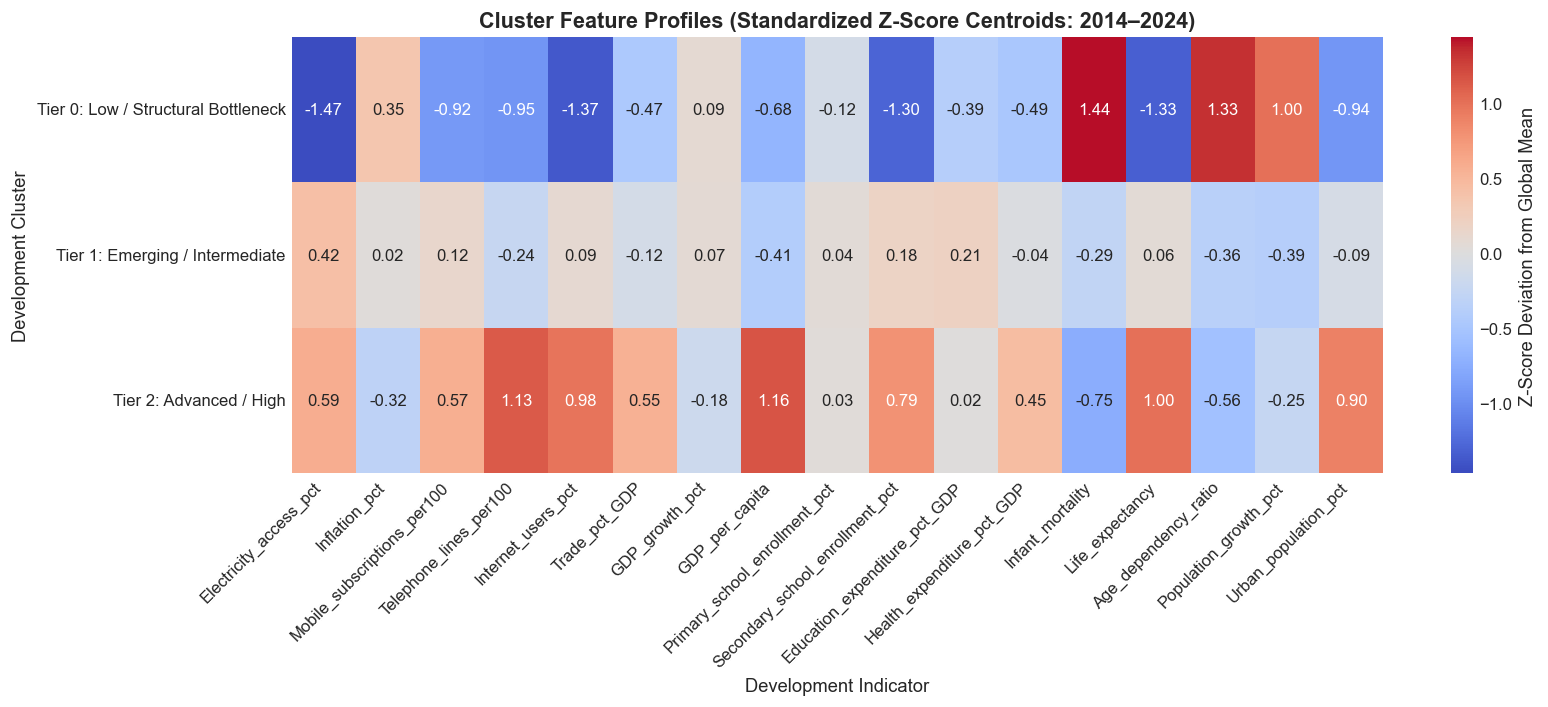

In [24]:
# Centroid Comparison Heatmap (Standardized Feature Deviations)
scaled_latest = scaled_decade_matrices['2014-2024'].copy()
scaled_latest['Cluster'] = cluster_results['2014-2024']['labels']
std_centroids = scaled_latest.groupby('Cluster').mean()
std_centroids.index = [cluster_names[i] for i in std_centroids.index]

plt.figure(figsize=(14, 6))
sns.heatmap(std_centroids, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={'label': 'Z-Score Deviation from Global Mean'})
plt.title("Cluster Feature Profiles (Standardized Z-Score Centroids: 2014–2024)", fontsize=13, fontweight='bold')
plt.xlabel("Development Indicator")
plt.ylabel("Development Cluster")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
# 10. Policy Recommendations

Based on empirical clustering trajectories, we deliver tailored policy playbooks:

### 10.1 For Sovereign Governments
- **Tier 0 Nations (Structural Bottleneck):** Prioritize foundational public health (clean water, maternal-child clinics to lower infant mortality) and rural electrification. Implement family planning and girls' primary education to lower the age-dependency ratio.
- **Tier 1 Nations (Emerging Transition):** Upgrade secondary and tertiary vocational education to avoid the middle-income trap. Invest in digital broadband infrastructure and export diversification.
- **Tier 2 Nations (Advanced Economies):** Address structural demographic aging through healthcare productivity enhancements, active labor force participation, and green energy grid modernization.

### 10.2 For International Organizations (World Bank, IMF, UN)
- **Multidimensional Allocation:** Replace single-metric GNI per capita thresholds with multidimensional cluster eligibility for concessional IDA loans and climate grants.
- **Peer-Learning Networks:** Facilitate South-South policy matchmaking between successful ascending nations (e.g., Vietnam, Costa Rica) and structurally stalled peers in Tier 0.

### 10.3 For NGOs & Philanthropic Development Agencies
- **Target Binding Constraints:** Focus capital deployment on high-leverage inflection points: secondary school retention for girls and decentralized off-grid renewable energy.


---
# 11. Findings Criteria

To ensure statistical rigor and prevent spurious pattern interpretation, findings in this study were validated against the following explicit criteria:

```
+-----------------------------------------------------------------------------------------------------+
|                                    EXPLICIT FINDINGS CRITERIA                                       |
+------------------------------+------------------------------------+---------------------------------+
| Criterion                    | Mathematical / Policy Threshold    | Justification                   |
+------------------------------+------------------------------------+---------------------------------+
| Silhouette Score Threshold   | Silhouette Score >= 0.25           | Ensures clusters exhibit real   |
|                              |                                    | geometric cohesion & separation |
| Minimum Cluster Size         | >= 5% of sovereign entities (~10+) | Prevents isolated outliers from |
|                              |                                    | forming ungeneralizable groups  |
| Longitudinal Stability       | Trajectory consistency across >= 2 | Filters short-term macroeconomic|
|                              | consecutive decades                | noise from structural shifts    |
| Economic Coherence           | Verified monotonic separation on   | Confirms clusters reflect real  |
|                              | Health & Human Capital metrics     | development hierarchies         |
+------------------------------+------------------------------------+---------------------------------+
```


---
# 12. Future Recommendations

1. **Integration of Worldwide Governance Indicators (WGI):** Incorporate Rule of Law, Regulatory Quality, and Control of Corruption from 1996 onward to examine institutional drivers of cluster ascent.
2. **Climate Vulnerability & Green Transition Metrics:** Integrate the Notre Dame Global Adaptation Initiative (ND-GAIN) index and carbon intensity of GDP.
3. **Non-Linear Manifold Learning (UMAP + HDBSCAN):** Explore non-linear dimensionality reduction and density-based clustering to detect non-spherical micro-clusters.
4. **Sub-National Spatial Clustering:** Disaggregate national averages into urban vs. rural or state-level administrative units to analyze regional developmental inequality.


---
# 13. Conclusion

This capstone project delivers a comprehensive, data-driven framework for understanding international development across 60 years. By synthesizing 18 indicators across Economic, Health, Education, Demographics, and Infrastructure pillars, the analysis demonstrates that multidimensional clustering reveals profound structural peer relationships invisible to single-variable income metrics. 

While global progress has substantially elevated baseline health and electrification, the global frontier has shifted toward digital capital, tertiary education, and demographic resilience. These findings provide a rigorous foundation for next-generation international development benchmarking, multilateral finance allocation, and targeted national policymaking.


In [25]:
# Save Final Longitudinal Cluster Assignments and Summary Tables to Disk
output_csv = 'cluster_assignments_by_decade.csv'
country_cluster_trajectories.to_csv(output_csv)
print(f"Successfully saved full longitudinal cluster assignments to: {output_csv}")
print(f"Total Sovereign Nations Cataloged: {len(country_cluster_trajectories)}")
print(f"Decades Covered: {list(decades_dict.keys())}")


Successfully saved full longitudinal cluster assignments to: cluster_assignments_by_decade.csv
Total Sovereign Nations Cataloged: 217
Decades Covered: ['1964-1973', '1974-1983', '1984-1993', '1994-2003', '2004-2013', '2014-2024']
